# Final ProtoHedge Paper Notebook

This notebook is the single consolidated paper notebook. It is designed to:

1. run the full synthetic Black--Scholes figure suite,
2. run the full synthetic stochastic-volatility figure suite,
3. run the real-data 10-ticker empirical sweep,
4. export tables and figures to one unified paper-assets directory, and
5. add the missing panel summary and interpretability figures needed for the paper.

The notebook is deliberately long. It is meant to replace the current split between `proto-trainer-torch.ipynb`, `real-data-tests-torch.ipynb`, and `real-data-panel-tests-torch.ipynb` for paper production.

In [2]:

from pathlib import Path
import sys
import os
import shutil
import json

cwd = Path.cwd().resolve()
if (cwd / 'world_real_torch.py').exists():
    REPO_ROOT = cwd
elif (cwd.parent / 'world_real_torch.py').exists():
    REPO_ROOT = cwd.parent
else:
    raise RuntimeError(f'Could not locate repo root from {cwd}')

os.environ.setdefault('MPLCONFIGDIR', str((REPO_ROOT / '.matplotlib-cache').resolve()))
Path(os.environ['MPLCONFIGDIR']).mkdir(parents=True, exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from IPython.display import display, Markdown

REPO_PARENT = REPO_ROOT.parent
repo_parent_str = str(REPO_PARENT)
sys.path = [p for p in sys.path if Path(p or '.').resolve() != REPO_PARENT]
sys.path.insert(0, repo_parent_str)
for mod_name in list(sys.modules):
    if mod_name == 'deephedging' or mod_name.startswith('deephedging.'):
        del sys.modules[mod_name]

from deephedging.run_train_torch import run_experiment
from deephedging.plots_proto_torch import plot_full_diagnostics
import deephedging.plot_bs_hedge_torch as plot_bs_hedge
from deephedging.proto_analysis_torch import (
    binned_terminal_pnl,
    ensure_bs_test_context,
    ensure_stoch_test_context,
    bs_prototype_usage,
    stochastic_prototype_usage,
    stochastic_similarity_details,
    bs_similarity_details,
    load_prototype_payload,
    resolve_pickle_path,
    extract_stochastic_path_features,
)
from deephedging.prototype_extraction_torch import extract_agent_feature_matrix
from deephedging.real_data_sweep_torch import run_real_data_sweep, MODEL_FEATURES
from deephedging.real_data_analysis_torch import (
    evaluate_saved_artifact,
    evaluate_saved_baselines,
    list_saved_artifacts,
    build_regime_frame,
    summarize_by_regime,
    prototype_usage_table,
    prototype_usage_by_regime,
    aggregate_regime_summaries,
)

pd.set_option('display.max_columns', 300)
pd.set_option('display.width', 220)
plt.rcParams['figure.dpi'] = 120

FINAL_RUN_ROOT = REPO_ROOT / '.deephedging_real_runs' / 'final_paper_notebook'
FINAL_RUN_ROOT.mkdir(parents=True, exist_ok=True)
PAPER_ASSET_DIR = REPO_ROOT / 'paper' / 'final_notebook_assets'
PAPER_ASSET_DIR.mkdir(parents=True, exist_ok=True)
PROTOTYPE_STORAGE_DIR = REPO_ROOT / 'notebooks' / 'prototypes_storage'
PROTOTYPE_STORAGE_DIR.mkdir(parents=True, exist_ok=True)

SYNTH_BS_DIR = PAPER_ASSET_DIR / 'synthetic_bs'
SYNTH_STOCH_DIR = PAPER_ASSET_DIR / 'synthetic_stochastic'
PANEL_ASSET_DIR = PAPER_ASSET_DIR / 'real_data_panel'
for _p in [SYNTH_BS_DIR, SYNTH_STOCH_DIR, PANEL_ASSET_DIR]:
    _p.mkdir(parents=True, exist_ok=True)


def _unique_path(path: Path) -> Path:
    path = Path(path)
    if not path.exists():
        return path
    stem = path.stem
    suffix = path.suffix
    i = 2
    while True:
        cand = path.with_name(f"{stem}_{i}{suffix}")
        if not cand.exists():
            return cand
        i += 1


def save_current_figure(name, subdir='misc', dpi=180):
    subdir_path = PAPER_ASSET_DIR / subdir
    subdir_path.mkdir(parents=True, exist_ok=True)
    path = _unique_path(subdir_path / f'{name}.png')
    plt.gcf().savefig(path, dpi=dpi, bbox_inches='tight')
    print('saved figure:', path)
    return path


def save_dataframe(df, name, subdir='tables', latex=True, index=False):
    subdir_path = PAPER_ASSET_DIR / subdir
    subdir_path.mkdir(parents=True, exist_ok=True)
    csv_path = subdir_path / f'{name}.csv'
    df.to_csv(csv_path, index=index)
    print('saved table:', csv_path)
    if latex:
        tex_path = subdir_path / f'{name}.tex'
        try:
            tex = df.to_latex(index=index, escape=False, float_format=lambda x: f"{x:.6f}" if isinstance(x, (float, np.floating)) else str(x))
            tex_path.write_text(tex)
            print('saved latex:', tex_path)
        except Exception as exc:
            print('latex export skipped:', exc)
    return csv_path


def maybe_copy(src, subdir='copied_assets'):
    src = Path(src)
    if not src.exists():
        print('missing asset:', src)
        return None
    dst_dir = PAPER_ASSET_DIR / subdir
    dst_dir.mkdir(parents=True, exist_ok=True)
    dst = _unique_path(dst_dir / src.name)
    shutil.copy2(src, dst)
    print('copied asset:', dst)
    return dst


def expanded_feature_cols(feature_names, world, input_dim):
    per_step = world.data.features.per_step
    n_inst = int(world.nInst)
    cols = []
    count = 0
    for name in sorted(feature_names or ['price', 'delta', 'time_left']):
        if name in per_step:
            arr = np.asarray(per_step[name])
            width = 1 if arr.ndim == 2 else int(arr.shape[-1])
        elif name in ['delta', 'action']:
            width = n_inst
        elif name in ['pnl', 'cost']:
            width = 1
        else:
            width = 1
        if width == 1:
            cols.append(name)
            count += 1
        else:
            for j in range(width):
                cols.append(f'{name}_{j}')
                count += 1
    if count != int(input_dim):
        cols = [f'feature_{i}' for i in range(int(input_dim))]
    return cols


def select_best_row(best_df, preferred_selection, fallback_selections=()):
    for selection in (preferred_selection, *fallback_selections):
        sub = best_df[best_df['selection'] == selection]
        if not sub.empty:
            return sub.iloc[0]
    raise ValueError(f'Could not find preferred selection {preferred_selection} in best_df')

print('repo root:', REPO_ROOT)
print('paper assets:', PAPER_ASSET_DIR)
print('prototype storage:', PROTOTYPE_STORAGE_DIR)


repo root: /Users/yaniszaim/deephedging
paper assets: /Users/yaniszaim/deephedging/paper/final_notebook_assets
prototype storage: /Users/yaniszaim/deephedging/notebooks/prototypes_storage


## Run Controls

These switches let you rerun only the sections you need. The notebook is configured for the full paper run by default.

In [3]:

RUN_SYNTHETIC_BS = True
RUN_SYNTHETIC_STOCH = True
RUN_PANEL_SWEEP = True
RUN_PANEL_ANALYSIS = True

SYNTHETIC_EPOCHS = 800
BS_SAMPLES = 10_000
STOCH_SAMPLES = 10_000


# Part I: Black--Scholes Synthetic Reproduction

## Vanilla Deep Hedging in Black--Scholes

In [4]:
print("Deep Hedging AI says hello (Torch) ... ", end='')
from IPython.display import display, Markdown
from deephedging.run_train_torch import run_experiment


display(Markdown("## Deep Hedging in a Black-Scholes World"))

results_bs = run_experiment(
    override_world={
        "samples": 10000,
        "steps": 20,
        "black_scholes": True,
    },
    override_objective={
        "risk_measure": "cvar",
        "risk_aversion": 1.0,
    },
    override_model={
        "agent_type": "feed_forward",
        "feature_list": ["price", "delta", "time_left"],
        "network_depth": 3,
        "network_width": 20,
        "activation": "softplus",
    },
    override_training={
        "lr": 1e-3,
        "batch_size": None,
        "epochs": 800,
        "epoch_refresh": 5,
        "clipvalue": 1.0,
        "global_clipnorm": 1.0,
        "lr_decay_factor": 0.5,
        "lr_decay_patience": 25,
        "lr_min": 1e-5,
        "scheduler_monitor": "val",
    },
)

config = results_bs["config"]
world = results_bs["world"]
val_world = results_bs["val_world"]
gym_vanilla = results_bs["gym"]
vanilla_bs_gym = gym_vanilla
r = results_bs["training_result"]

print("Keys of the dictionary returned by the gym: ", r.keys())
print("=========================================")
print("Torch config")
print("=========================================")
print(config)


Deep Hedging AI says hello (Torch) ... 

## Deep Hedging in a Black-Scholes World


PyTorch version 2.11.0 running on 8 CPUs and 0 GPUs
epoch 0 | batch 0.1973 | train 0.1887 | val 0.1801 | select 0.1887
epoch 5 | batch 0.1789 | train 0.1778 | val 0.1708 | select 0.1778
epoch 10 | batch 0.1677 | train 0.1675 | val 0.1619 | select 0.1675
epoch 15 | batch 0.1658 | train 0.1649 | val 0.1596 | select 0.1649
epoch 20 | batch 0.1655 | train 0.1649 | val 0.1598 | select 0.1649
epoch 25 | batch 0.1655 | train 0.1648 | val 0.1595 | select 0.1648
epoch 30 | batch 0.1656 | train 0.1651 | val 0.1599 | select 0.1651
epoch 35 | batch 0.1657 | train 0.1647 | val 0.1596 | select 0.1647
epoch 40 | batch 0.1654 | train 0.1649 | val 0.1595 | select 0.1649
epoch 45 | batch 0.1659 | train 0.1647 | val 0.1595 | select 0.1647
epoch 50 | batch 0.1654 | train 0.1663 | val 0.1613 | select 0.1663
epoch 55 | batch 0.1657 | train 0.1647 | val 0.1596 | select 0.1647
epoch 60 | batch 0.1655 | train 0.1649 | val 0.1598 | select 0.1649
epoch 65 | batch 0.1650 | train 0.1648 | val 0.1596 | select 0.16

## ProtoHedge in Black--Scholes

In [5]:
# In your notebook or training script:
import pickle
from deephedging.run_train_torch import run_experiment
from deephedging.plots_proto_torch import plot_full_diagnostics
from deephedging.proto_analysis_torch import resolve_pickle_path

# 1. Load configuration
config = {}
n_prototypes = 100
proto_path = str(PROTOTYPE_STORAGE_DIR / f"prototypes_{n_prototypes}.pkl")

# 2. World setup
try:
    with open(resolve_pickle_path(proto_path), "rb") as f:
        prototypes = pickle.load(f)
except FileNotFoundError:
    prototypes = None
    print("Prototype file not found yet; torch will generate it during training.")

results_proto_bs = run_experiment(
    override_world={
        "samples": 10000,
        "steps": 20,
        "black_scholes": True,
    },
    override_model={
        "agent_type": "protopnet",
        "prototype_path": proto_path,
        "feature_list": ["price", "delta", "time_left"],
    },
    override_objective={
        "risk_measure": "cvar",
        "risk_aversion": 1.0,
    },
    override_training={
        "lr": 1e-3,
        "epochs": 800,
        "batch_size": None,
        "epoch_refresh": 5,
        "clipvalue": 1.0,
        "global_clipnorm": 1.0,
        "lr_decay_factor": 0.5,
        "lr_decay_patience": 25,
        "lr_min": 1e-5,
        "scheduler_monitor": "val",
    },
)

config = results_proto_bs["config"]
world = results_proto_bs["world"]
val_world = results_proto_bs["val_world"]
gym = results_proto_bs["gym"]
r = results_proto_bs["training_result"]

print("Keys of the dictionary returned by the gym: ", r.keys())
print("=========================================")
print("Torch config")
print("=========================================")
print(config)



PyTorch version 2.11.0 running on 8 CPUs and 0 GPUs
epoch 0 | batch 0.1830 | train 0.1760 | val 0.1682 | select 0.1760
epoch 5 | batch 0.1662 | train 0.1655 | val 0.1598 | select 0.1655
epoch 10 | batch 0.1624 | train 0.1620 | val 0.1560 | select 0.1620
epoch 15 | batch 0.1611 | train 0.1611 | val 0.1555 | select 0.1611
epoch 20 | batch 0.1608 | train 0.1608 | val 0.1556 | select 0.1608
epoch 25 | batch 0.1605 | train 0.1602 | val 0.1551 | select 0.1602
epoch 30 | batch 0.1604 | train 0.1600 | val 0.1551 | select 0.1600
epoch 35 | batch 0.1604 | train 0.1599 | val 0.1550 | select 0.1599
epoch 40 | batch 0.1603 | train 0.1600 | val 0.1551 | select 0.1600
epoch 45 | batch 0.1601 | train 0.1599 | val 0.1550 | select 0.1599
epoch 50 | batch 0.1601 | train 0.1600 | val 0.1549 | select 0.1600
epoch 55 | batch 0.1601 | train 0.1600 | val 0.1551 | select 0.1600
epoch 60 | batch 0.1602 | train 0.1599 | val 0.1550 | select 0.1599
epoch 65 | batch 0.1601 | train 0.1600 | val 0.1549 | select 0.16

In [6]:
# In your notebook or training script:
import pickle
from deephedging.run_train_torch import run_experiment
from deephedging.plots_proto_torch import plot_full_diagnostics
from deephedging.proto_analysis_torch import resolve_pickle_path

# 1. Load configuration
config = {}
n_prototypes = 100
weighted_proto_path = str(PROTOTYPE_STORAGE_DIR / f"prototypes_{n_prototypes}.pkl")

# 2. World setup
try:
    with open(resolve_pickle_path(weighted_proto_path), "rb") as f:
        prototypes = pickle.load(f)
except FileNotFoundError:
    prototypes = None
    print("Prototype file not found yet; torch will generate it during training.")

results_proto_bs_weighted = run_experiment(
    override_world={
        "samples": 10000,
        "steps": 20,
        "black_scholes": True,
    },
    override_model={
        "agent_type": "protopnet",
        "prototype_path": weighted_proto_path,
        "feature_list": ["price", "delta", "time_left"],
        "weighted_similarity": True,
        "distance_feature_weights": [1.0, 1.0, 5.0],
    },
    override_objective={
        "risk_measure": "cvar",
        "risk_aversion": 1.0,
    },
    override_training={
        "lr": 1e-3,
        "epochs": 800,
        "batch_size": None,
        "epoch_refresh": 5,
        "clipvalue": 1.0,
        "global_clipnorm": 1.0,
        "lr_decay_factor": 0.5,
        "lr_decay_patience": 25,
        "lr_min": 1e-5,
        "scheduler_monitor": "val",
    },
)

config = results_proto_bs_weighted["config"]
world = results_proto_bs_weighted["world"]
val_world = results_proto_bs_weighted["val_world"]
gym = results_proto_bs_weighted["gym"]
r = results_proto_bs_weighted["training_result"]

print("Keys of the dictionary returned by the gym: ", r.keys())
print("=========================================")
print("Torch config")
print("=========================================")
print(config)
print("Feature weights:", results_proto_bs_weighted["model"].feature_weights.detach().cpu().numpy())



PyTorch version 2.11.0 running on 8 CPUs and 0 GPUs
epoch 0 | batch 0.1883 | train 0.1854 | val 0.1772 | select 0.1854
epoch 5 | batch 0.1761 | train 0.1750 | val 0.1676 | select 0.1750
epoch 10 | batch 0.1715 | train 0.1744 | val 0.1680 | select 0.1744
epoch 15 | batch 0.1640 | train 0.1636 | val 0.1580 | select 0.1636
epoch 20 | batch 0.1630 | train 0.1651 | val 0.1596 | select 0.1651
epoch 25 | batch 0.1628 | train 0.1623 | val 0.1568 | select 0.1623
epoch 30 | batch 0.1625 | train 0.1616 | val 0.1563 | select 0.1616
epoch 35 | batch 0.1619 | train 0.1609 | val 0.1554 | select 0.1609
epoch 40 | batch 0.1618 | train 0.1609 | val 0.1555 | select 0.1609
epoch 45 | batch 0.1616 | train 0.1614 | val 0.1559 | select 0.1614
epoch 50 | batch 0.1610 | train 0.1626 | val 0.1572 | select 0.1626
epoch 55 | batch 0.1611 | train 0.1604 | val 0.1551 | select 0.1604
epoch 60 | batch 0.1608 | train 0.1611 | val 0.1558 | select 0.1611
epoch 65 | batch 0.1607 | train 0.1611 | val 0.1559 | select 0.16

## Black--Scholes Dashboards

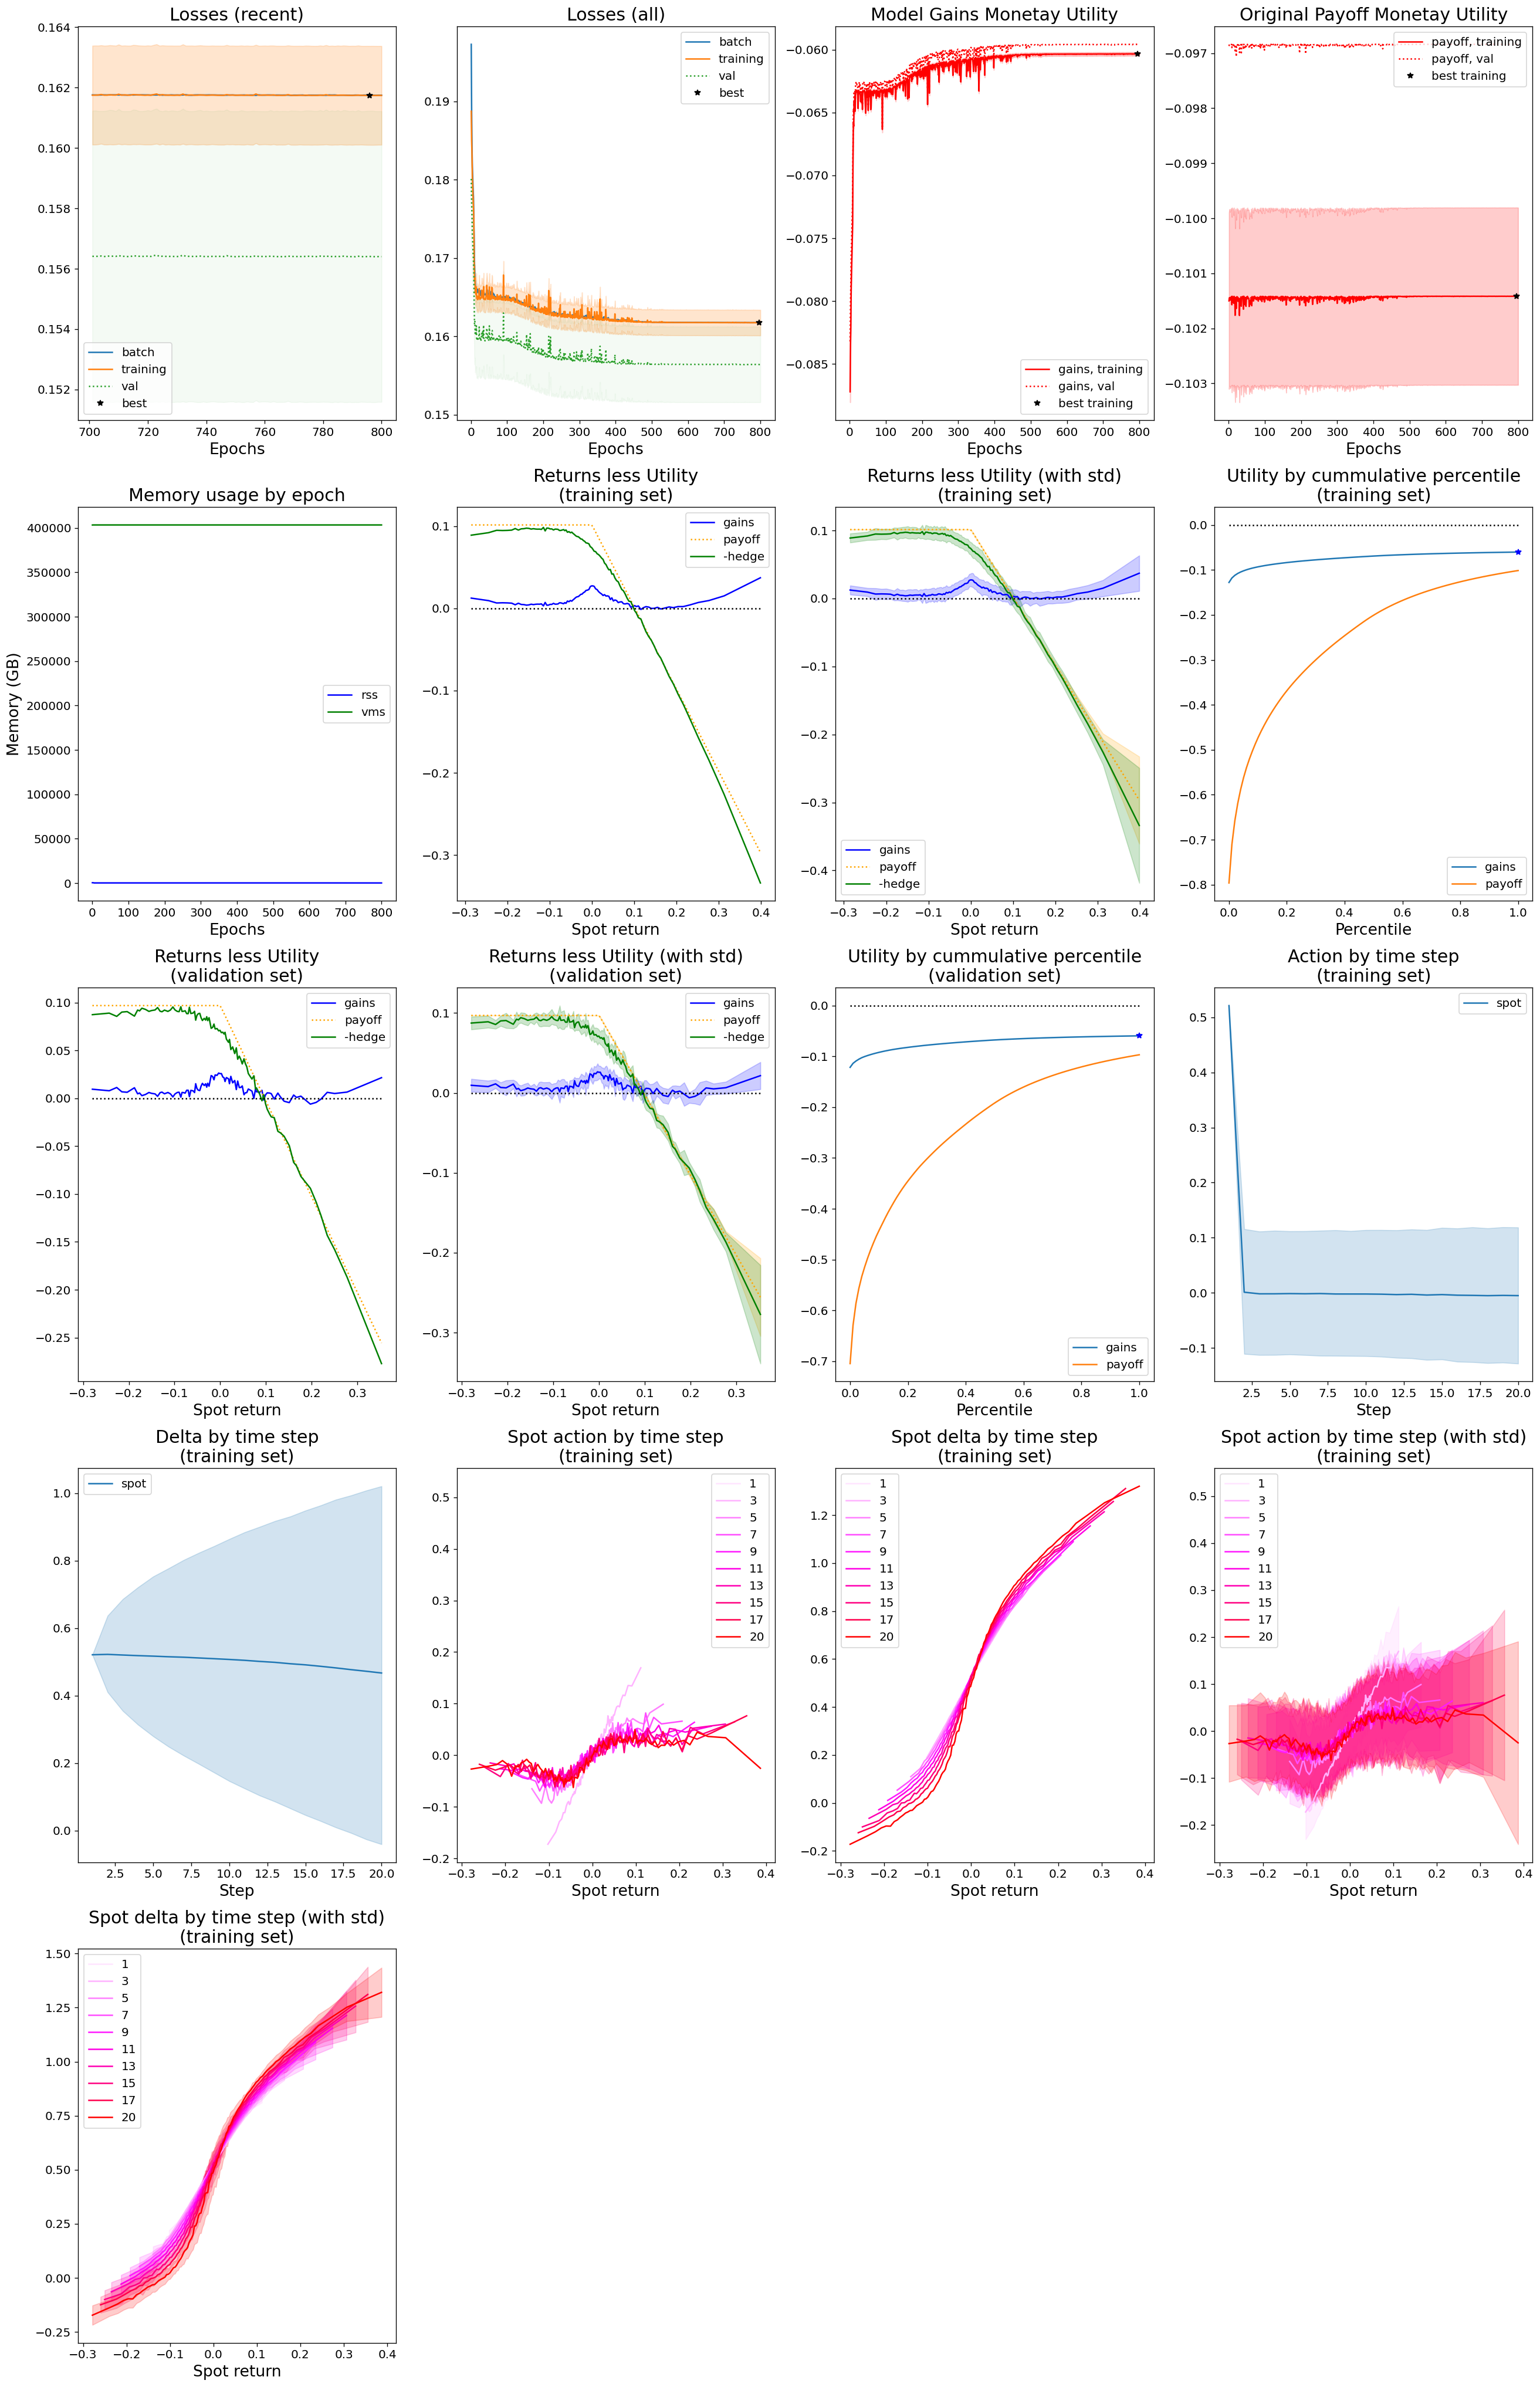

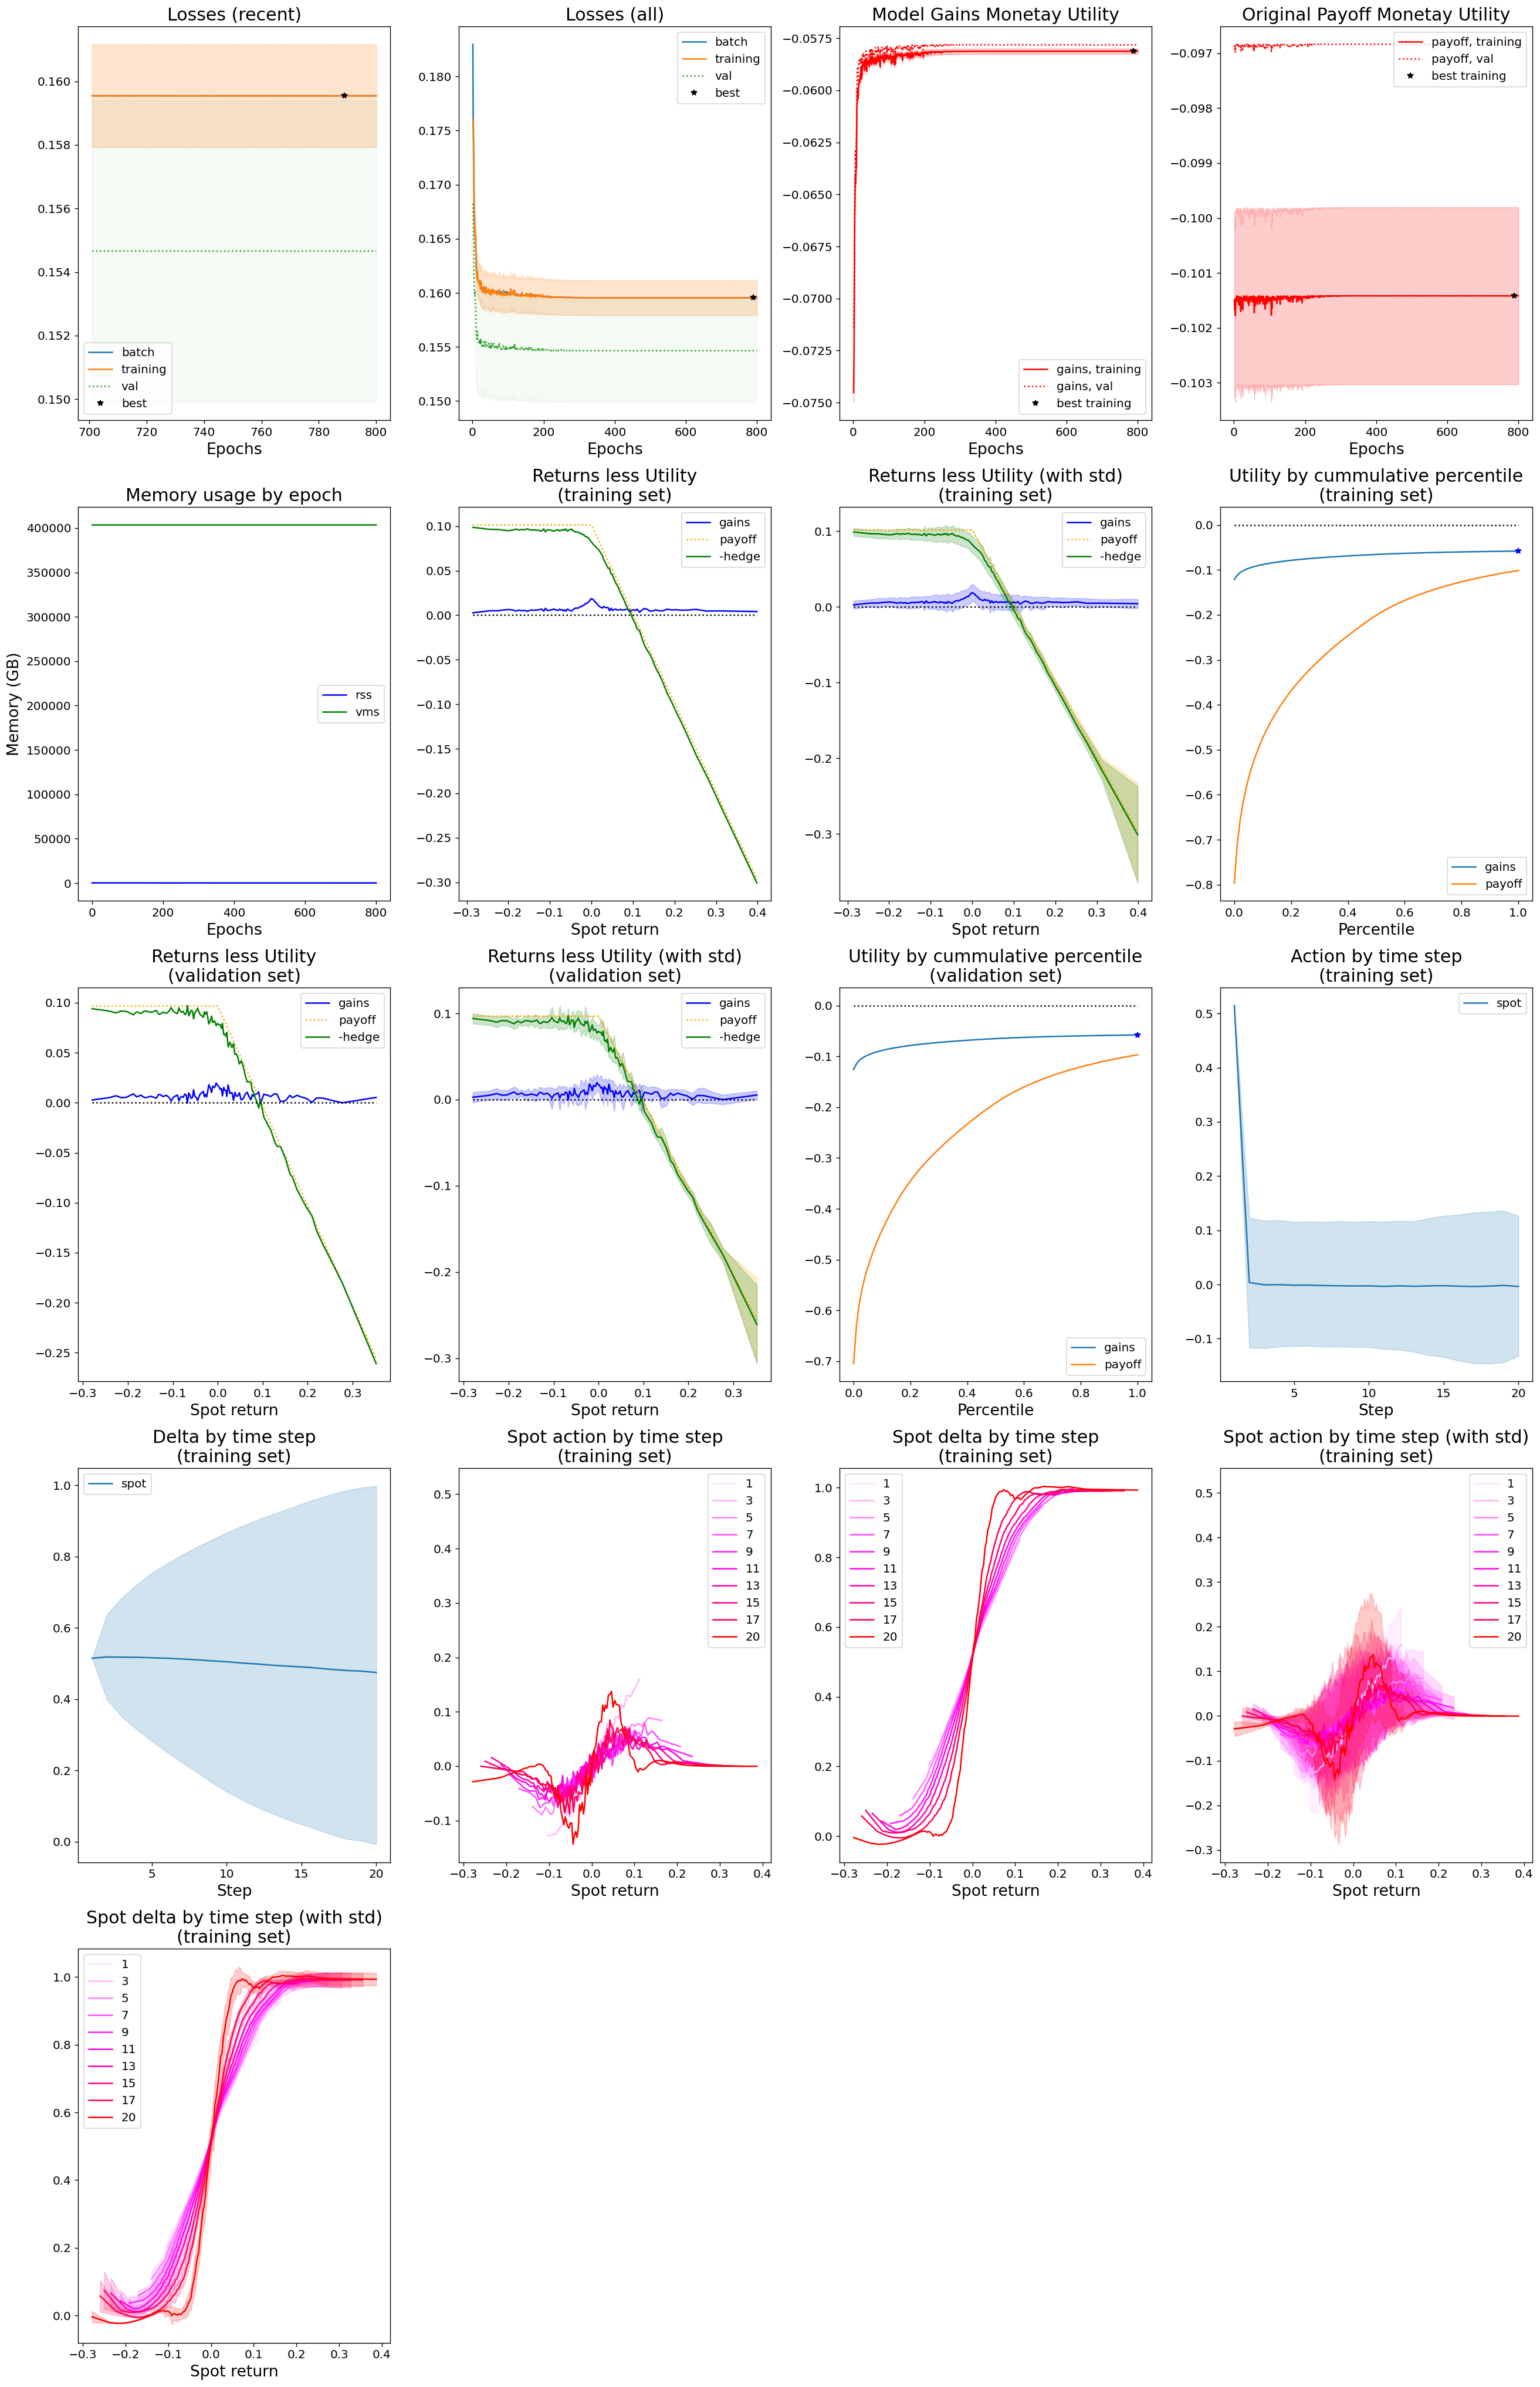

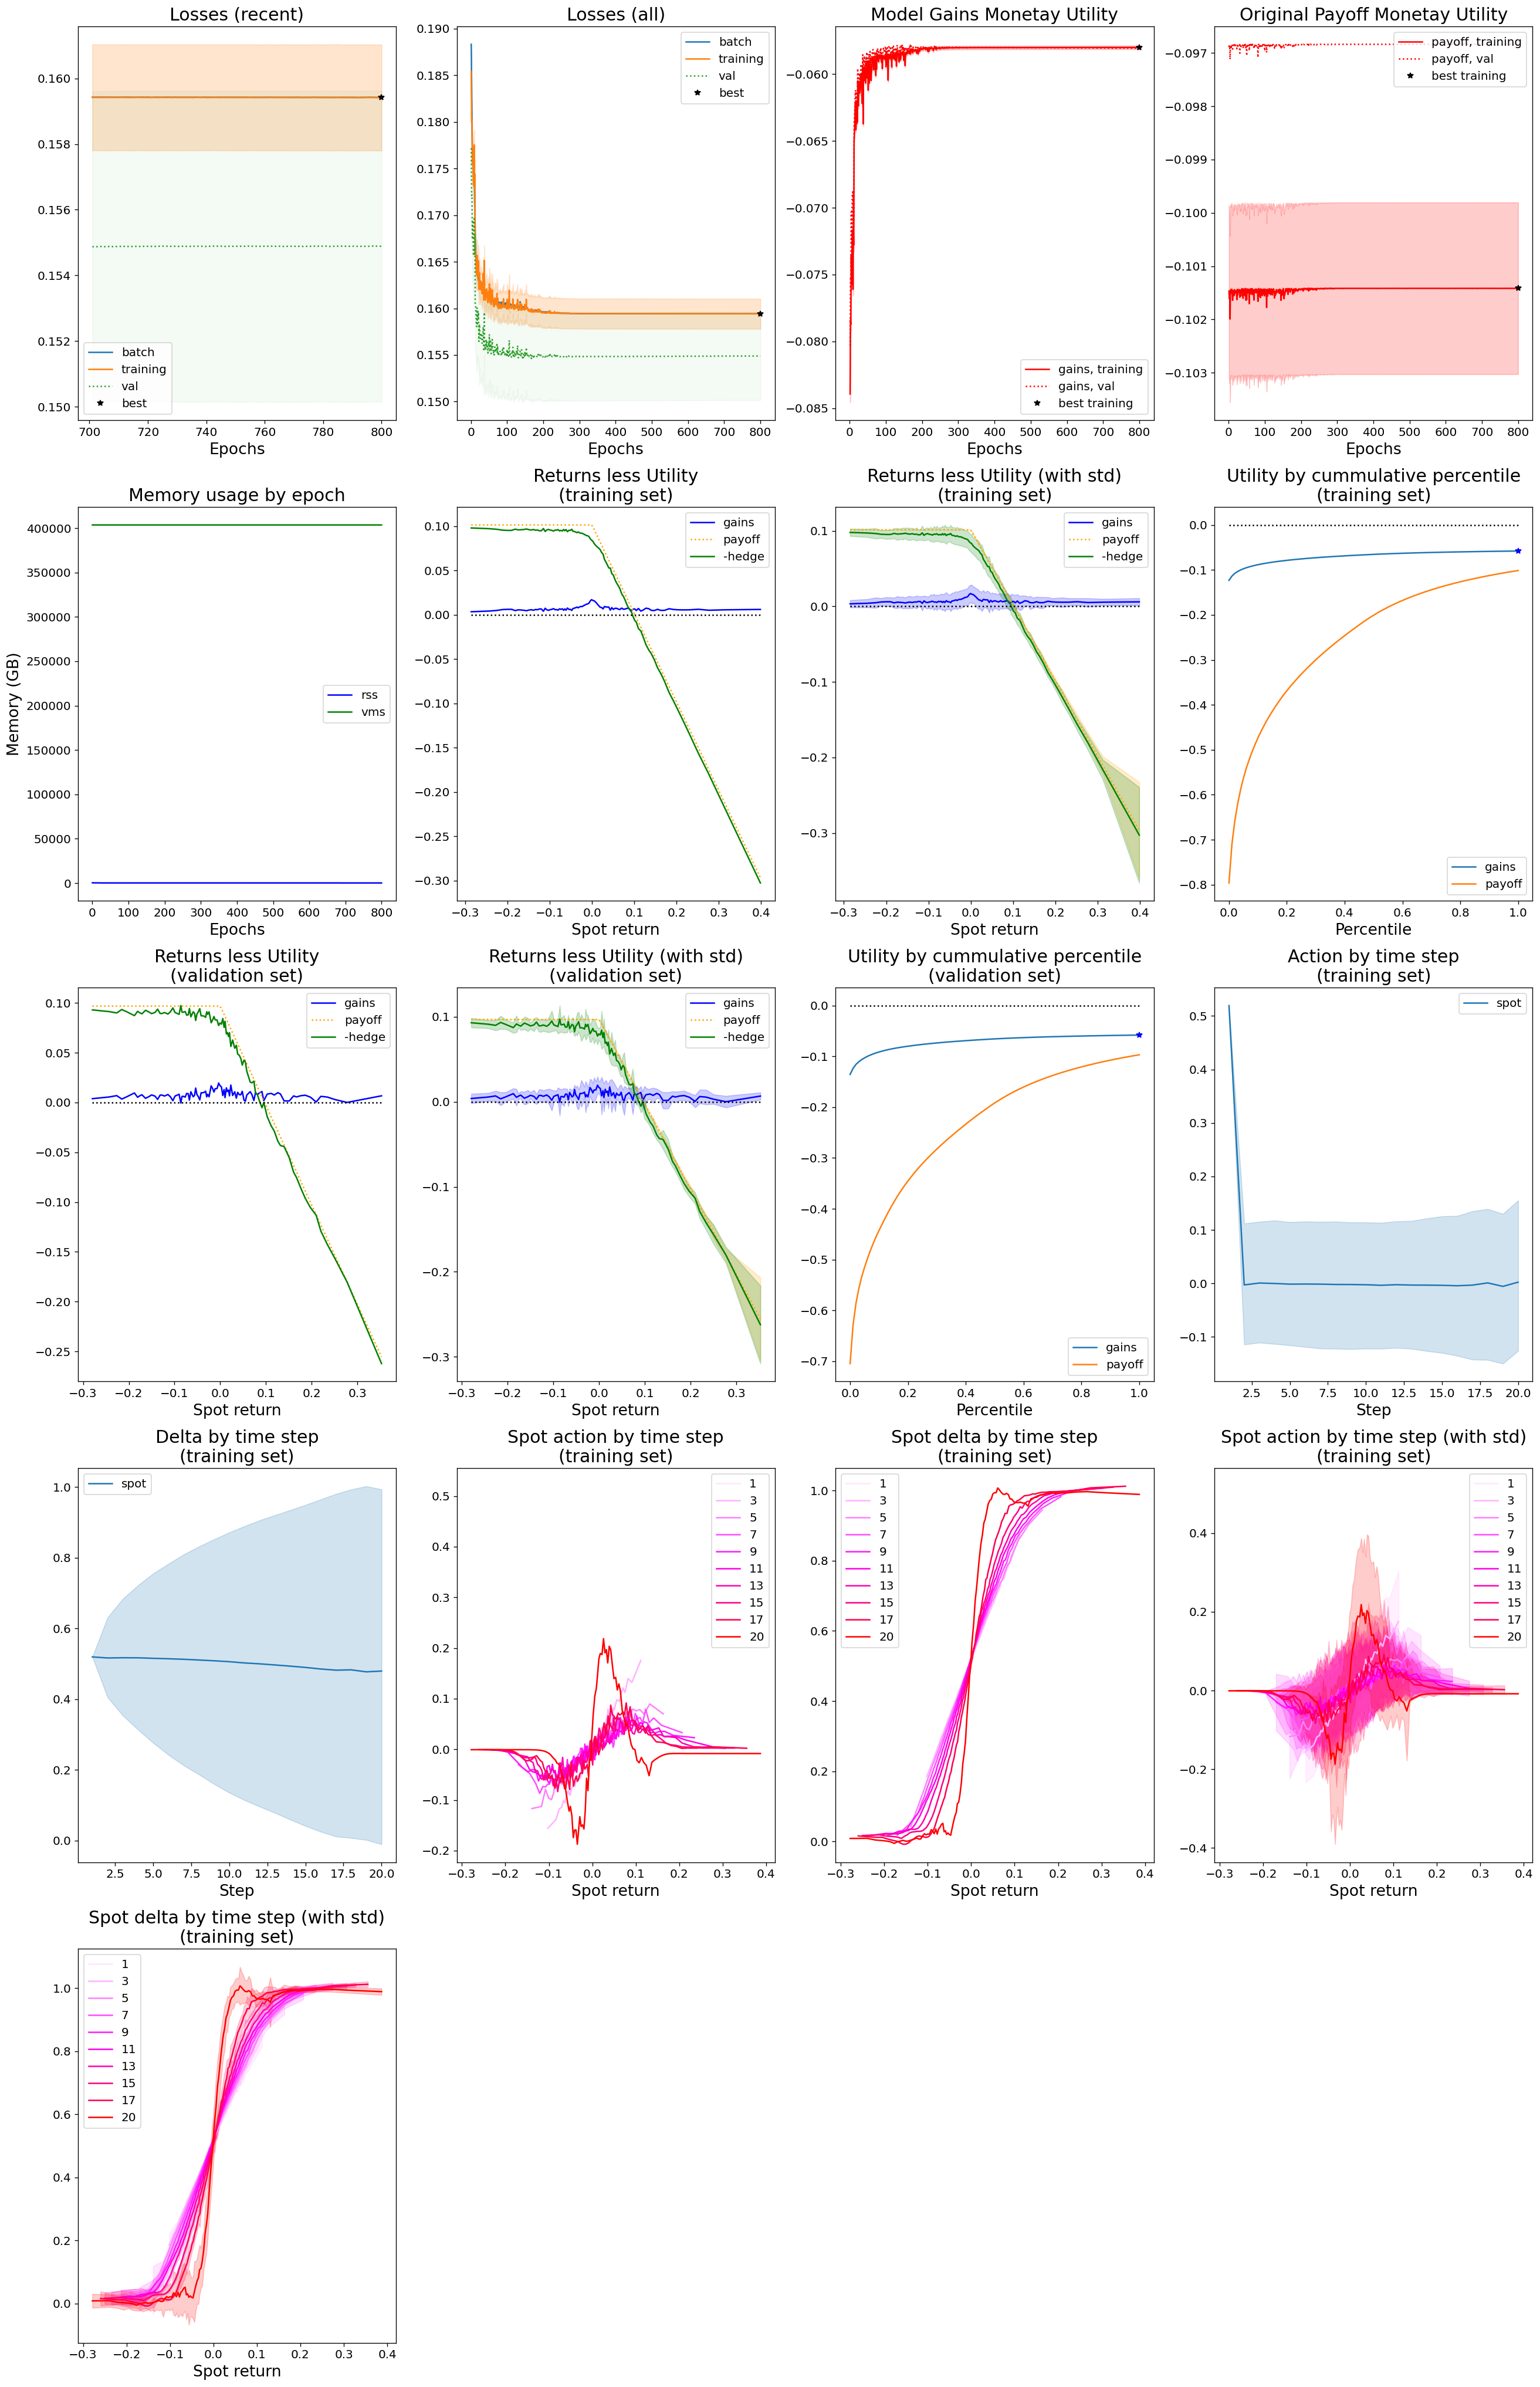

In [7]:

if RUN_SYNTHETIC_BS:
    _ = plot_full_diagnostics(results_bs, save_prefix=str(SYNTH_BS_DIR / 'vanilla_dashboard'))
    _ = plot_full_diagnostics(results_proto_bs, save_prefix=str(SYNTH_BS_DIR / 'proto_unweighted_dashboard'))
    _ = plot_full_diagnostics(results_proto_bs_weighted, save_prefix=str(SYNTH_BS_DIR / 'proto_weighted_dashboard'))


## Black--Scholes Analysis and Inference Figures

saved figure: /Users/yaniszaim/deephedging/paper/final_notebook_assets/synthetic_bs/bs_terminal_pnl_vs_spot.png


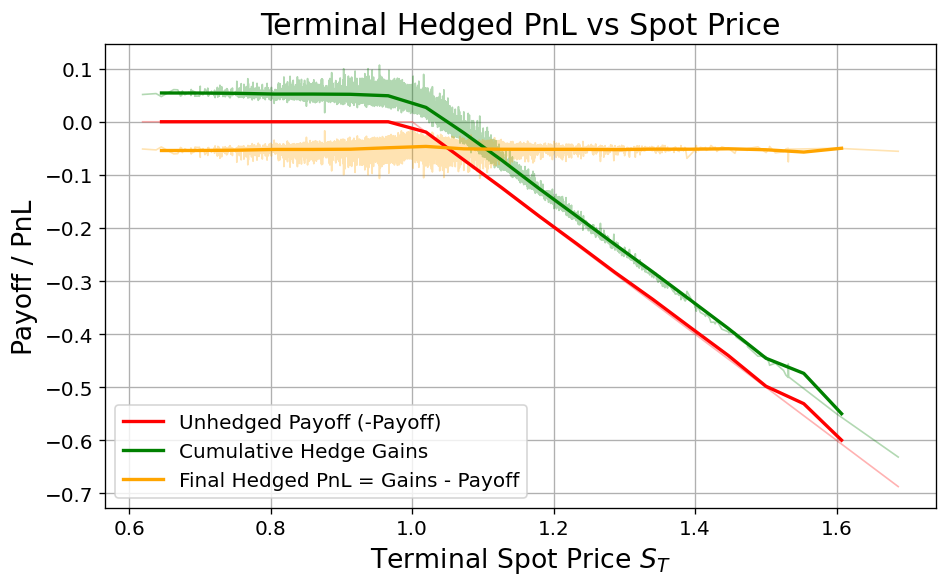

In [8]:
import matplotlib.pyplot as plt
from deephedging.proto_analysis_torch import binned_terminal_pnl

bs_train_analysis = binned_terminal_pnl(
    results_proto_bs_weighted["world"],
    results_proto_bs_weighted["training_result"],
    n_bins=20,
    use_raw_pnl=False,
)

plt.figure(figsize=(8, 5))
plt.plot(bs_train_analysis["sorted_spot_t"], bs_train_analysis["sorted_payoff"], label="_nolegend_", color="red", alpha=0.3, linewidth=1)
plt.plot(bs_train_analysis["sorted_spot_t"], bs_train_analysis["sorted_gains"], label="_nolegend_", color="green", alpha=0.3, linewidth=1)
plt.plot(bs_train_analysis["sorted_spot_t"], bs_train_analysis["sorted_total"], label="_nolegend_", color="orange", alpha=0.3, linewidth=1)

plt.plot(bs_train_analysis["bin_centers"], bs_train_analysis["payoff_binned"], label="Unhedged Payoff (-Payoff)", color="red", linewidth=2)
plt.plot(bs_train_analysis["bin_centers"], bs_train_analysis["gains_binned"], label="Cumulative Hedge Gains", color="green", linewidth=2)
plt.plot(bs_train_analysis["bin_centers"], bs_train_analysis["total_binned"], label="Final Hedged PnL = Gains - Payoff", color="orange", linewidth=2)

plt.xlabel("Terminal Spot Price $S_T$")
plt.ylabel("Payoff / PnL")
plt.title("Terminal Hedged PnL vs Spot Price")
plt.legend()
plt.grid(True)
plt.tight_layout()
save_current_figure('bs_terminal_pnl_vs_spot', subdir='synthetic_bs')
plt.show()


Running strategies ...done


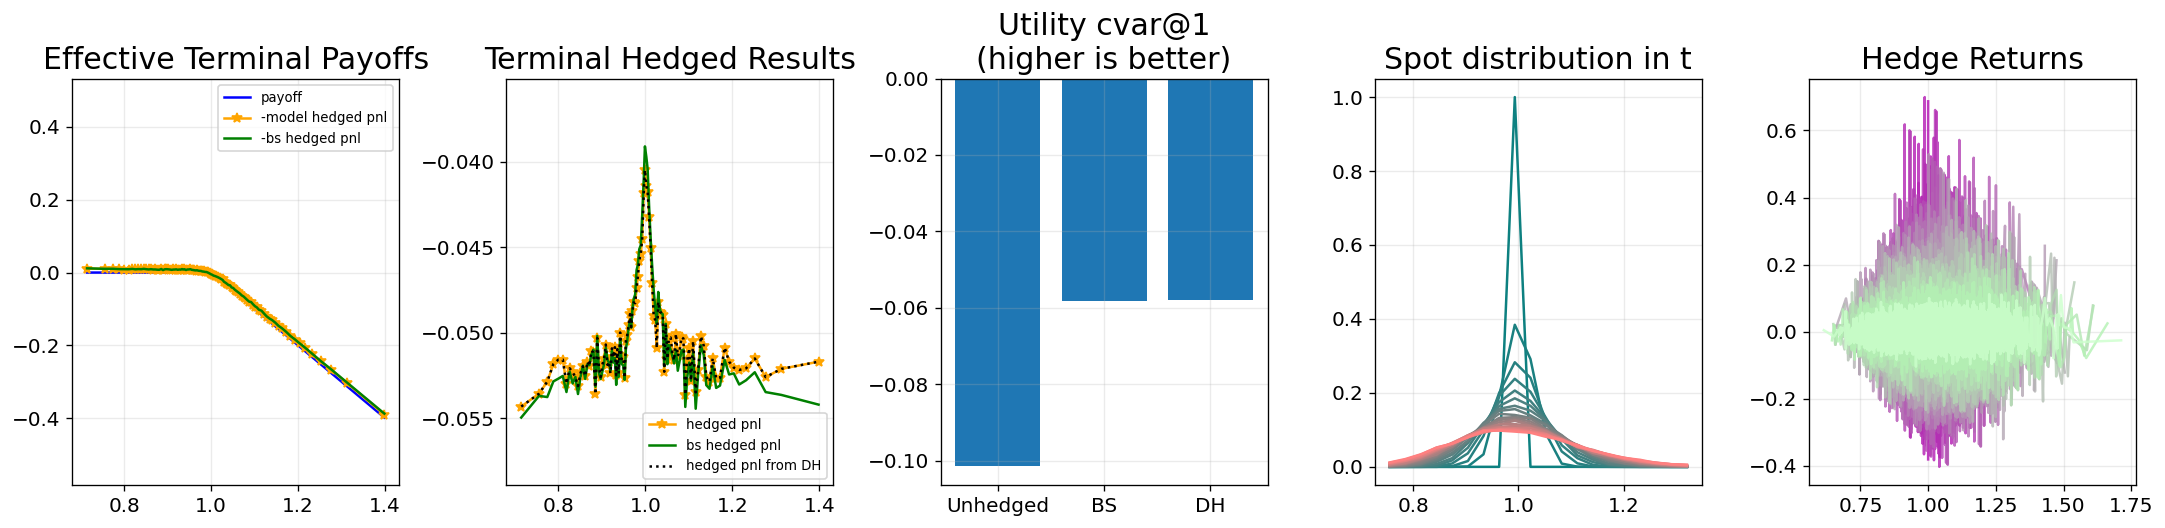

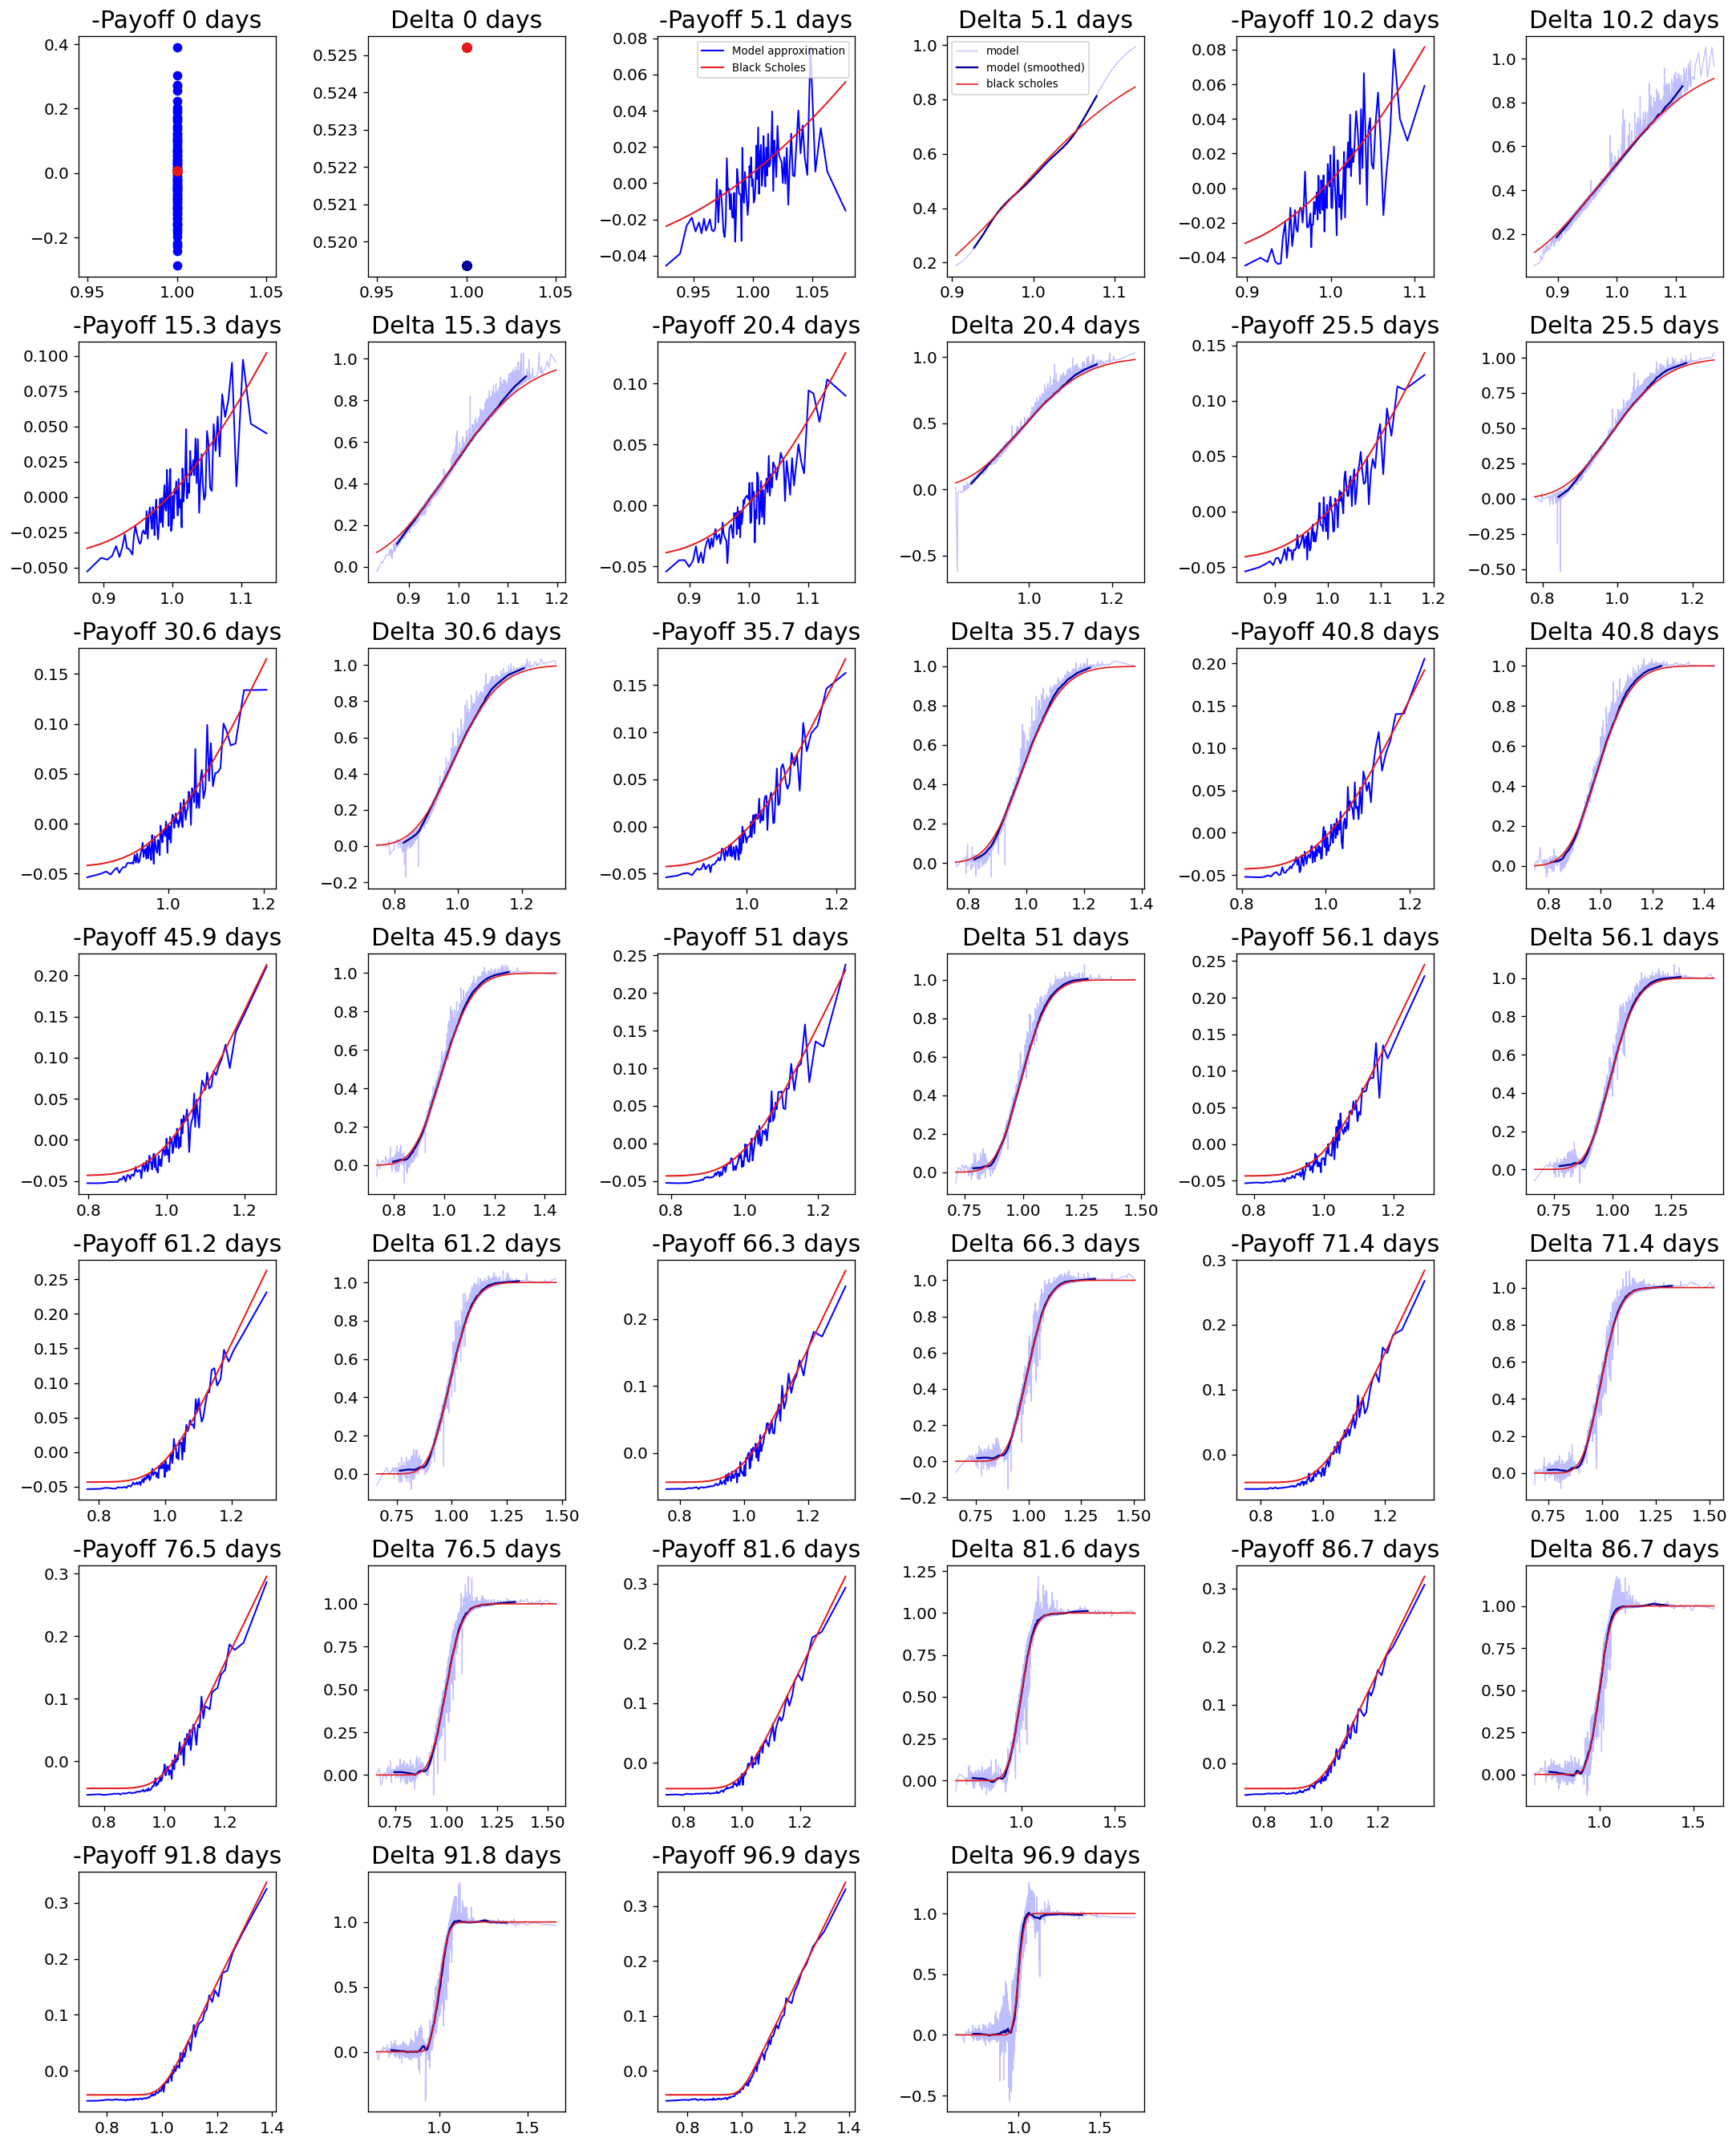

In [9]:

_ = plot_bs_hedge.plot_blackscholes(
    results_proto_bs_weighted['world'],
    results_proto_bs_weighted['gym'],
    results_proto_bs_weighted['config'],
    save_prefix=str(SYNTH_BS_DIR / 'bs_proto_weighted_hedge_comparison'),
)


saved figure: /Users/yaniszaim/deephedging/paper/final_notebook_assets/synthetic_bs/bs_raw_payoff_vs_spot_return.png


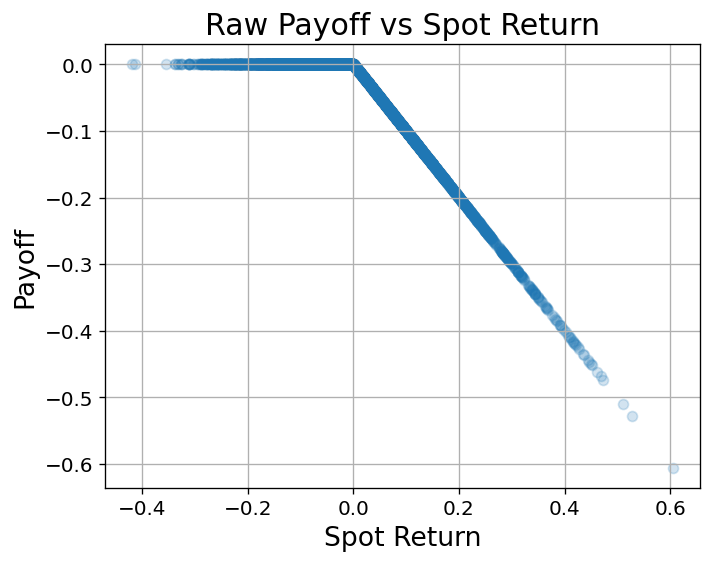

In [10]:
from deephedging.proto_analysis_torch import ensure_bs_test_context

bs_test_world, bs_test_result, bs_test_result_vanilla, results_bs = ensure_bs_test_context(
    results_proto_bs_weighted=results_proto_bs_weighted,
    results_bs=globals().get("results_bs"),
    seed=1,
    samples=5000,
)

spot_return = bs_test_world.details.spot_all[:, -1] - 1.0
payoff = bs_test_result["payoff"].numpy()

import matplotlib.pyplot as plt
plt.scatter(spot_return, payoff, alpha=0.2)
plt.xlabel("Spot Return")
plt.ylabel("Payoff")
plt.title("Raw Payoff vs Spot Return")
plt.grid(True)
save_current_figure('bs_raw_payoff_vs_spot_return', subdir='synthetic_bs')
plt.show()

saved figure: /Users/yaniszaim/deephedging/paper/final_notebook_assets/synthetic_bs/bs_tail_utility_examples.png


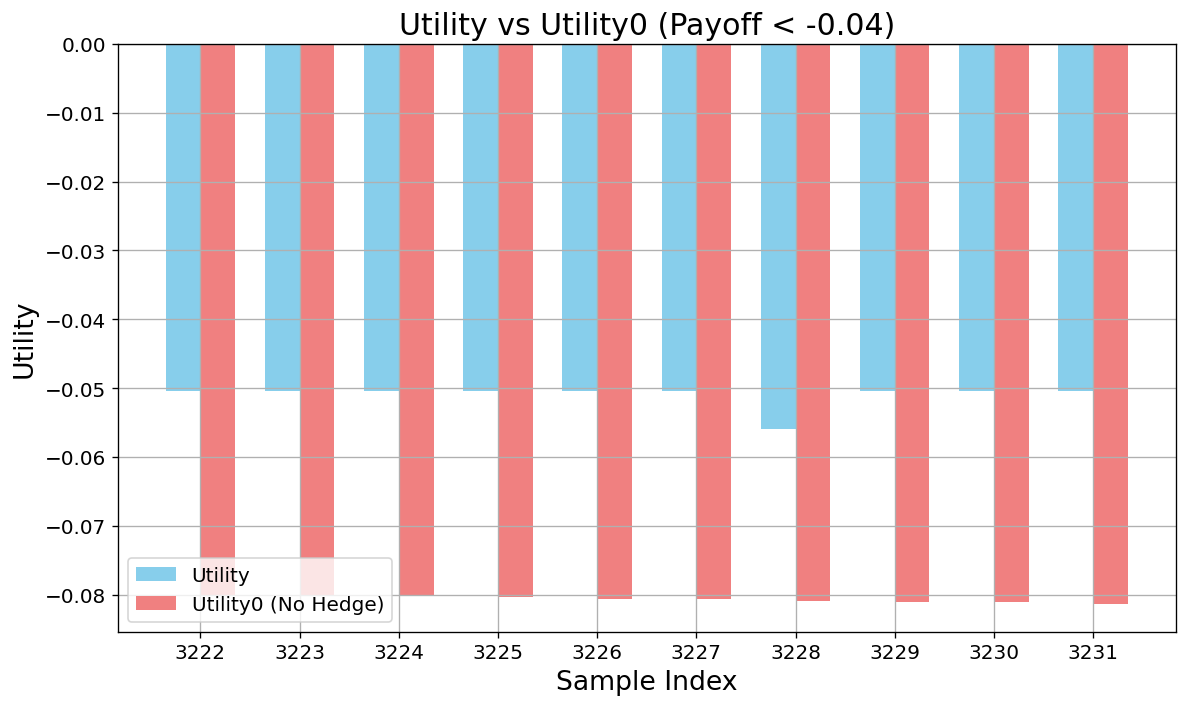

In [11]:
from deephedging.proto_analysis_torch import ensure_bs_test_context

bs_test_world, bs_test_result, bs_test_result_vanilla, results_bs = ensure_bs_test_context(
    results_proto_bs_weighted=results_proto_bs_weighted,
    results_bs=globals().get("results_bs"),
    seed=1,
    samples=5000,
)

import matplotlib.pyplot as plt
import numpy as np

# Extract utility, utility0, and payoff
utility = bs_test_result["utility"].numpy()
utility0 = bs_test_result["utility0"].numpy()
payoff = bs_test_result["payoff"].numpy()

# Find indices where payoff < 0 (i.e., short option was exercised)
negative_payoff_indices = np.where(payoff <= -0.04)[0]

# Take the first 10 of those
selected_indices = negative_payoff_indices[:10]
if len(selected_indices) == 0:
    print("No samples with payoff < -0.04 found.")
else:
    bar_width = 0.35
    indices = np.arange(len(selected_indices))

    plt.figure(figsize=(10, 6))
    plt.bar(indices, utility[selected_indices], width=bar_width, label='Utility', color='skyblue')
    plt.bar(indices + bar_width, utility0[selected_indices], width=bar_width, label='Utility0 (No Hedge)', color='lightcoral')

    plt.xlabel("Sample Index")
    plt.ylabel("Utility")
    plt.title("Utility vs Utility0 (Payoff < -0.04)")
    plt.xticks(indices + bar_width / 2, [str(i) for i in selected_indices])
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    save_current_figure('bs_tail_utility_examples', subdir='synthetic_bs')
plt.show()

saved figure: /Users/yaniszaim/deephedging/paper/final_notebook_assets/synthetic_bs/bs_prototype_usage.png


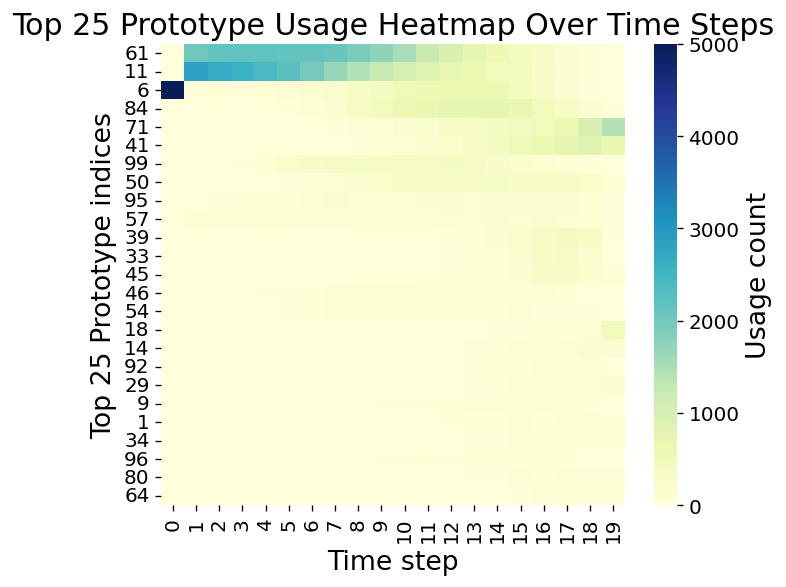

saved figure: /Users/yaniszaim/deephedging/paper/final_notebook_assets/synthetic_bs/bs_prototype_usage_2.png


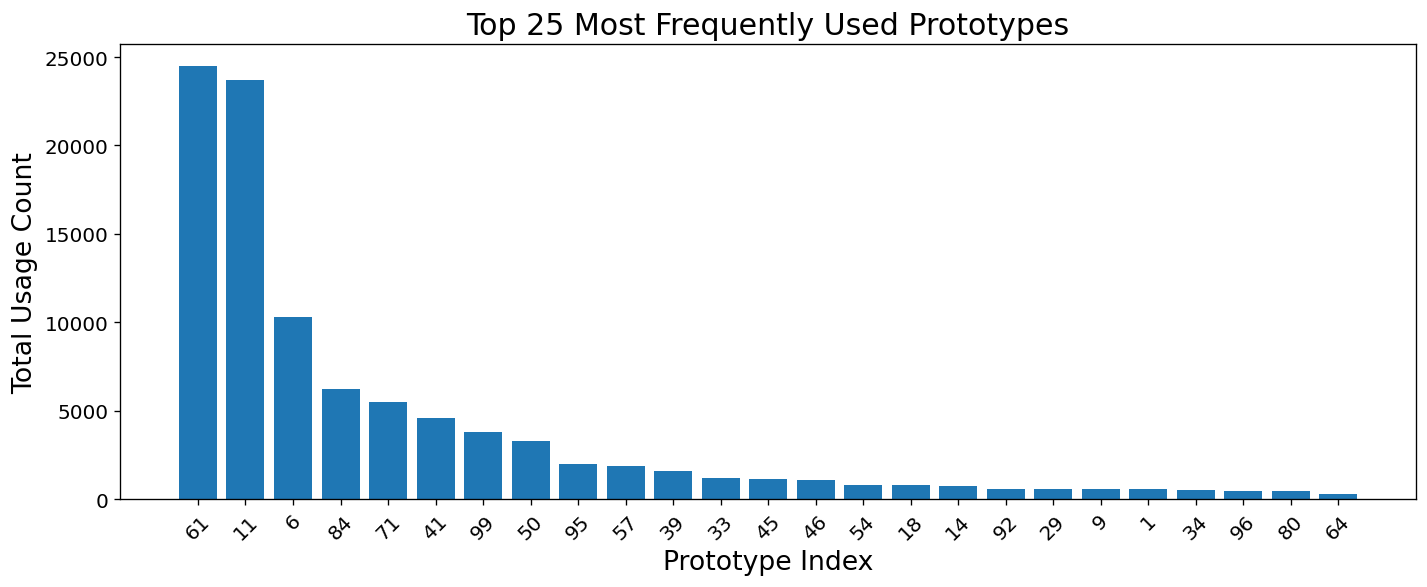

In [12]:
from deephedging.proto_analysis_torch import ensure_bs_test_context

bs_test_world, bs_test_result, bs_test_result_vanilla, results_bs = ensure_bs_test_context(
    results_proto_bs_weighted=results_proto_bs_weighted,
    results_bs=globals().get("results_bs"),
    seed=1,
    samples=5000,
)

import matplotlib.pyplot as plt
import seaborn as sns
from deephedging.proto_analysis_torch import bs_prototype_usage

bs_usage = bs_prototype_usage(
    agent=results_proto_bs_weighted["model"],
    world=bs_test_world,
    result=bs_test_result,
    prototype_path=weighted_proto_path,
    top_n=25,
)

globals()["bs_usage"] = bs_usage
heatmap = bs_usage["heatmap"]
top_25_idx = bs_usage["top_indices"]
filtered_heatmap = bs_usage["top_heatmap"]
totals = bs_usage["totals"]
top_25_vals = bs_usage["top_totals"]

plt.figure(figsize=(6, 5))
sns.heatmap(filtered_heatmap, cmap="YlGnBu", cbar_kws={"label": "Usage count"}, yticklabels=top_25_idx)
plt.xlabel("Time step")
plt.ylabel("Top 25 Prototype indices")
plt.title("Top 25 Prototype Usage Heatmap Over Time Steps")
plt.tight_layout()
save_current_figure('bs_prototype_usage', subdir='synthetic_bs')
plt.show()

plt.figure(figsize=(12, 5))
plt.bar(range(25), top_25_vals, tick_label=top_25_idx)
plt.xlabel("Prototype Index")
plt.ylabel("Total Usage Count")
plt.title("Top 25 Most Frequently Used Prototypes")
plt.xticks(rotation=45)
plt.tight_layout()
save_current_figure('bs_prototype_usage', subdir='synthetic_bs')
plt.show()


In [13]:
from deephedging.proto_analysis_torch import ensure_bs_test_context, bs_prototype_usage, load_prototype_payload

bs_test_world, bs_test_result, bs_test_result_vanilla, results_bs = ensure_bs_test_context(
    results_proto_bs_weighted=results_proto_bs_weighted,
    results_bs=globals().get("results_bs"),
    seed=1,
    samples=5000,
)

bs_usage = globals().get("bs_usage")
if bs_usage is None:
    bs_usage = bs_prototype_usage(
        agent=results_proto_bs_weighted["model"],
        world=bs_test_world,
        result=bs_test_result,
        prototype_path=weighted_proto_path,
        top_n=25,
    )
    globals()["bs_usage"] = bs_usage

top_25_idx = bs_usage["top_indices"]

import numpy as np
import pandas as pd
from IPython.display import display

payload = load_prototype_payload(weighted_proto_path)
scaler = payload["scaler"]
prototypes_np = payload["prototypes"]
proto_actions_np = results_proto_bs_weighted["model"].prototype_actions.detach().cpu().numpy()

top_10_idx = np.array(top_25_idx[:10], dtype=int)
top_10_prototypes = prototypes_np[top_10_idx]
top_10_actions = proto_actions_np[top_10_idx]
original_features = scaler.inverse_transform(top_10_prototypes)

df = pd.DataFrame(original_features, columns=["delta", "price", "time_left"])
df["action"] = top_10_actions[:, 0]
df["prototype_index"] = top_10_idx

df = df[["prototype_index", "delta", "price", "time_left", "action"]]

display(df.style.set_caption("Top 10 Most-Used Prototypes with Features and Actions"))

save_dataframe(df, 'bs_top10_prototypes', subdir='synthetic_bs/tables', latex=True)


AttributeError: The '.style' accessor requires jinja2

In [ ]:
from deephedging.proto_analysis_torch import ensure_bs_test_context, load_prototype_payload

bs_test_world, bs_test_result, bs_test_result_vanilla, results_bs = ensure_bs_test_context(
    results_proto_bs_weighted=results_proto_bs_weighted,
    results_bs=globals().get("results_bs"),
    seed=1,
    samples=5000,
)

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

payload = load_prototype_payload(weighted_proto_path)
scaler = payload["scaler"]
prototypes = payload["prototypes"]
proto_actions = results_proto_bs_weighted["model"].prototype_actions.detach().cpu().numpy()

prototypes_raw = scaler.inverse_transform(prototypes)
price_1 = prototypes_raw[:, 1]
delta_1 = prototypes_raw[:, 0]
time_left = prototypes_raw[:, 2]
action_1 = proto_actions[:, 0]

globals()["price_1"] = price_1
globals()["delta_1"] = delta_1
globals()["time_left"] = time_left
globals()["action_1"] = action_1

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
p = ax.scatter(price_1, delta_1, time_left, c=action_1, cmap='coolwarm', s=20)

ax.set_xlabel("Price 1")
ax.set_ylabel("Delta 1")
ax.set_zlabel("Time Left")
fig.colorbar(p, ax=ax, label="Action for Instrument 1")
ax.set_title("Prototype Space (Price 1, Delta 1, Time Left)")

plt.tight_layout()
save_current_figure('bs_prototype_space_3d', subdir='synthetic_bs')
plt.show()


In [ ]:
from deephedging.proto_analysis_torch import ensure_bs_test_context, load_prototype_payload

bs_test_world, bs_test_result, bs_test_result_vanilla, results_bs = ensure_bs_test_context(
    results_proto_bs_weighted=results_proto_bs_weighted,
    results_bs=globals().get("results_bs"),
    seed=1,
    samples=5000,
)

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

payload = load_prototype_payload(weighted_proto_path)
scaler = payload["scaler"]
prototypes = payload["prototypes"]
proto_actions = results_proto_bs_weighted["model"].prototype_actions.detach().cpu().numpy()
prototypes_raw = scaler.inverse_transform(prototypes)
price_1 = prototypes_raw[:, 1]
delta_1 = prototypes_raw[:, 0]
action_1 = proto_actions[:, 0]

# Set symmetric color limits around 0
abs_max = np.max(np.abs(action_1))
symmetric_limit = np.ceil(abs_max * 5) / 10
norm = TwoSlopeNorm(vmin=-symmetric_limit, vcenter=0.0, vmax=symmetric_limit)

plt.figure(figsize=(7, 5))
sc = plt.scatter(price_1, delta_1, c=action_1, cmap='coolwarm', norm=norm, s=20)
plt.xlabel("Spot Price", fontsize=14)
plt.ylabel("Spot Delta", fontsize=14)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.axvline(x=1.0, color='gray', linestyle='--', linewidth=1)

cbar = plt.colorbar(sc, shrink=0.8, pad=0.02)
cbar.set_label("Action", fontsize=14)

plt.tight_layout()
save_current_figure('bs_prototype_space_2d', subdir='synthetic_bs')
plt.show()


In [ ]:
from deephedging.proto_analysis_torch import ensure_bs_test_context

bs_test_world, bs_test_result, bs_test_result_vanilla, results_bs = ensure_bs_test_context(
    results_proto_bs_weighted=results_proto_bs_weighted,
    results_bs=globals().get("results_bs"),
    seed=1,
    samples=5000,
)

import matplotlib.pyplot as plt

# Utilities
utilities = {
    'Unhedged': bs_test_result_vanilla["utility0"].numpy().mean(),
    'BS': -0.0516349,
    'DH': bs_test_result_vanilla["utility"].numpy().mean(),
    'ProtoHedge': bs_test_result["utility"].numpy().mean()
}

labels = list(utilities.keys())
values = list(utilities.values())
colors = ['gray', 'blue', 'orange', 'green']

# Plot
plt.figure(figsize=(6, 5))
bars = plt.bar(labels, values, color=colors)

plt.ylabel('Expected Utility', fontsize=16)
plt.xticks(fontsize=16)
# plt.title('Expected Utility Comparison (CVaR@50%) in Black-Scholes World')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add black text below the top of each bar
for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width() / 2, val - 0.0055, f"{val:.5f}",
             ha='center', va='bottom', color='black', fontsize=14)

plt.tight_layout()
save_current_figure('bs_expected_utility_comparison', subdir='synthetic_bs')
plt.show()

In [ ]:

bs_test_world, bs_test_result, bs_test_result_vanilla, results_bs = ensure_bs_test_context(
    results_proto_bs_weighted=results_proto_bs_weighted,
    results_bs=globals().get('results_bs'),
    seed=1,
    samples=5000,
)
bs_summary_table = pd.DataFrame([
    {'model': 'Unhedged', 'expected_utility': float(bs_test_result_vanilla['utility0'].numpy().mean())},
    {'model': 'Vanilla DH', 'expected_utility': float(bs_test_result_vanilla['utility'].numpy().mean())},
    {'model': 'ProtoHedge (weighted)', 'expected_utility': float(bs_test_result['utility'].numpy().mean())},
])
save_dataframe(bs_summary_table, 'bs_expected_utility_table', subdir='synthetic_bs/tables', latex=True)
display(bs_summary_table)


# Part II: Stochastic-Volatility Synthetic Reproduction

## Vanilla Deep Hedging in the Stochastic World

In [ ]:
print("Deep Hedging AI says hello  ... ", end='')
from IPython.display import display, Markdown
from deephedging.run_train_torch import run_experiment


display(Markdown("## Deep Hedging in a simple Stochastic Volatility World"))

results_stoch_vanilla = run_experiment(
    override_world={
        "samples": 10000,
        "steps": 20,
        "black_scholes": False,
    },
    override_objective={
        "risk_measure": "cvar",
        "risk_aversion": 1.0,
    },
    override_model={
        "agent_type": "feed_forward",
        "feature_list": ["price", "delta", "time_left"],
        "network_depth": 3,
        "network_width": 20,
        "activation": "softplus",
    },
    override_training={
        "lr": 1e-3,
        "batch_size": None,
        "epochs": 800,
        "epoch_refresh": 5,
        "clipvalue": 1.0,
        "global_clipnorm": 1.0,
        "lr_decay_factor": 0.5,
        "lr_decay_patience": 25,
        "lr_min": 1e-5,
        "scheduler_monitor": "val",
    },
)

config = results_stoch_vanilla["config"]
world = results_stoch_vanilla["world"]
val_world = results_stoch_vanilla["val_world"]
vanilla_stoch_gym = results_stoch_vanilla["gym"]
vanilla_stoch_model = vanilla_stoch_gym
r = results_stoch_vanilla["training_result"]

print("Keys of the dictionary returned by the gym: ", r.keys())
print("=========================================")
print("Torch config")
print("=========================================")
print(config)


## ProtoHedge in the Stochastic World

In [ ]:
print("Deep Hedging AI says hello  ... ", end='')
import pickle
from pathlib import Path
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances_argmin_min
from threadpoolctl import threadpool_limits
from IPython.display import display, Markdown
from deephedging.run_train_torch import run_experiment
from deephedging.proto_analysis_torch import resolve_pickle_path

# ============================
# 1. Load configuration
config = {}

n_prototypes = 500
prototype_path_stoch = str(PROTOTYPE_STORAGE_DIR / f"prototypes_stochastic_{n_prototypes}.pkl")

try:
    resolved_proto_path = resolve_pickle_path(prototype_path_stoch)
except FileNotFoundError:
    resolved_proto_path = PROTOTYPE_STORAGE_DIR / f"prototypes_stochastic_{n_prototypes}.pkl"

if not resolved_proto_path.exists():
    print("Stochastic prototype file not found; building it from the vanilla stochastic policy.")
    price = world.data.features.per_step['price']
    time_left = world.data.features.per_step['time_left']
    actions = results_stoch_vanilla['training_result']['actions'].numpy()
    delta = np.cumsum(actions, axis=1) - actions

    X_all = np.stack(
        [
            delta[:, :, 0],
            delta[:, :, 1],
            price[:, :, 0],
            price[:, :, 1],
            time_left,
        ],
        axis=2,
    ).reshape(-1, 5)

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_all)

    with threadpool_limits(limits=1):
        kmeans = KMeans(n_clusters=n_prototypes, random_state=0, n_init="auto")
        labels = kmeans.fit_predict(X_scaled)
        real_prototypes = []
        for cluster_idx in range(n_prototypes):
            cluster_points = X_scaled[labels == cluster_idx]
            if len(cluster_points) == 0:
                continue
            center = kmeans.cluster_centers_[cluster_idx].reshape(1, -1)
            closest_idx, _ = pairwise_distances_argmin_min(center, cluster_points)
            real_prototypes.append(cluster_points[closest_idx[0]])

    payload = {
        "prototypes": np.stack(real_prototypes, axis=0),
        "scaler": scaler,
    }
    resolved_proto_path.parent.mkdir(parents=True, exist_ok=True)
    with open(resolved_proto_path, "wb") as f:
        pickle.dump(payload, f)
    print(f"Saved stochastic prototypes to {resolved_proto_path}")

with open(resolved_proto_path, "rb") as f:
    prototypes = pickle.load(f)

prototype_path_stoch = str(resolved_proto_path)

display(Markdown("## Deep Hedging in a simple Stochastic Volatility World"))

results_proto_stoch = run_experiment(
    override_world={
        "samples": 10000,
        "steps": 20,
        "black_scholes": False,
    },
    override_model={
        "agent_type": "protopnet",
        "prototype_path": prototype_path_stoch,
        "feature_list": ["price", "delta", "time_left"],
        "weighted_similarity": True,
        "distance_feature_weights": [1.0, 1.0, 1.0, 1.0, 1.0],
        "learn_distance_feature_weights": True,
    },
    override_objective={
        "risk_measure": "cvar",
        "risk_aversion": 1.0,
    },
    override_training={
        "lr": 1e-3,
        "epochs": 800,
        "batch_size": None,
        "epoch_refresh": 5,
        "clipvalue": 1.0,
        "global_clipnorm": 1.0,
        "lr_decay_factor": 0.5,
        "lr_decay_patience": 25,
        "lr_min": 1e-5,
        "scheduler_monitor": "val",
    },
)

config = results_proto_stoch["config"]
world = results_proto_stoch["world"]
val_world = results_proto_stoch["val_world"]
gym = results_proto_stoch["gym"]
r = results_proto_stoch["training_result"]

print("Keys of the dictionary returned by the gym: ", r.keys())
print("=========================================")
print("Torch config")
print("=========================================")
print(config)
print("Feature weights:", gym.agent.feature_weights.detach().cpu().numpy())


In [ ]:

if RUN_SYNTHETIC_STOCH:
    _ = plot_full_diagnostics(results_stoch_vanilla, save_prefix=str(SYNTH_STOCH_DIR / 'vanilla_dashboard'))
    _ = plot_full_diagnostics(results_proto_stoch, save_prefix=str(SYNTH_STOCH_DIR / 'proto_dashboard'))


## Stochastic-Volatility Analysis and Inference Figures

In [ ]:
import matplotlib.pyplot as plt
from deephedging.proto_analysis_torch import binned_terminal_pnl

stoch_train_analysis = binned_terminal_pnl(world, r, n_bins=50, use_raw_pnl=True)

plt.figure(figsize=(8, 5))
plt.plot(stoch_train_analysis["sorted_spot_t"], stoch_train_analysis["sorted_payoff"], label="_nolegend_", color="red", alpha=0.3, linewidth=1)
plt.plot(stoch_train_analysis["sorted_spot_t"], stoch_train_analysis["sorted_gains"], label="_nolegend_", color="green", alpha=0.3, linewidth=1)
plt.plot(stoch_train_analysis["sorted_spot_t"], stoch_train_analysis["sorted_total"], label="_nolegend_", color="orange", alpha=0.3, linewidth=1)

plt.plot(stoch_train_analysis["bin_centers"], stoch_train_analysis["payoff_binned"], label="Unhedged PnL (-Payoff)", color="red", linewidth=2)
plt.plot(stoch_train_analysis["bin_centers"], stoch_train_analysis["gains_binned"], label="Cumulative Hedge (Gains)", color="green", linewidth=2)
plt.plot(stoch_train_analysis["bin_centers"], stoch_train_analysis["total_binned"], label="Gains - Payoff", color="orange", linewidth=2)

plt.xlabel("Terminal Spot Price $S_T$")
plt.ylabel("PnL")
plt.legend()
plt.grid(True)
plt.tight_layout()
save_current_figure('stoch_terminal_pnl_vs_spot', subdir='synthetic_stochastic')
plt.show()


In [ ]:
from deephedging.proto_analysis_torch import ensure_stoch_test_context

stoch_test_world, stoch_test_data, stoch_test_result, stoch_test_result_vanilla, results_stoch_vanilla = ensure_stoch_test_context(
    results_proto_stoch=results_proto_stoch,
    results_stoch_vanilla=globals().get("results_stoch_vanilla"),
    seed=42,
    samples=5000,
)
import matplotlib.pyplot as plt
import numpy as np
from deephedging.proto_analysis_torch import extract_stochastic_path_features

stoch_path_num = globals().get("stoch_path_num", -100)
path = extract_stochastic_path_features(stoch_test_world, stoch_test_result, stoch_path_num)
price = path["price"]
time_left = path["time_left"]
actions = path["actions"]
delta = path["delta"]

delta_1 = path["delta_1"]
delta_2 = path["delta_2"]
price_1 = path["price_1"]
price_2 = path["price_2"]
X = path["x"]

steps = np.arange(X.shape[0])

fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.set_xlabel('Time Step', fontsize=16)
ax1.set_ylabel('Delta', color='tab:blue', fontsize=16)
ax1.plot(steps, delta_1, label='Underlying Asset Delta', color='tab:blue', linewidth=2)
ax1.plot(steps, delta_2, label='ATM Option Delta', color='tab:cyan', linewidth=2)
ax1.tick_params(axis='y', labelsize=16, labelcolor='tab:blue')
ax1.tick_params(axis='x', labelsize=16)
ax1.legend(loc='upper left')

ax2 = ax1.twinx()
ax2.set_ylabel('Price', color='tab:red', fontsize=16)
ax2.plot(steps, price_1, label='Spot Price', color='tab:red', linestyle='--')
ax2.tick_params(axis='y', labelcolor='tab:red', labelsize=16)
ax2.legend(loc='upper right')

plt.grid(True)
plt.tight_layout()
save_current_figure('stoch_representative_path', subdir='synthetic_stochastic')
plt.show()


In [ ]:
from deephedging.proto_analysis_torch import ensure_stoch_test_context

stoch_test_world, stoch_test_data, stoch_test_result, stoch_test_result_vanilla, results_stoch_vanilla = ensure_stoch_test_context(
    results_proto_stoch=results_proto_stoch,
    results_stoch_vanilla=globals().get("results_stoch_vanilla"),
    seed=42,
    samples=5000,
)
import matplotlib.pyplot as plt
import numpy as np
from deephedging.proto_analysis_torch import stochastic_similarity_details, load_prototype_payload

stoch_path_num = globals().get("stoch_path_num", -100)
stoch_path_details = globals().get("stoch_path_details")
if stoch_path_details is None:
    stoch_path_details = stochastic_similarity_details(
        agent=results_proto_stoch["model"],
        world=stoch_test_world,
        result=stoch_test_result,
        prototype_path=prototype_path_stoch,
        path_num=stoch_path_num,
        top_k=3,
    )

payload = load_prototype_payload(prototype_path_stoch)
scaler = payload["scaler"]
prototypes = payload["prototypes"]
X_scaled = stoch_path_details["x_scaled"]
similarities = stoch_path_details["similarities"]

t = 10
x_input_scaled = X_scaled[t]
x_input_raw = scaler.inverse_transform([x_input_scaled])[0]

top3_idx = np.argsort(-similarities[t])[:10]
prototypes_scaled = prototypes[top3_idx]
prototypes_raw = scaler.inverse_transform(prototypes_scaled)

vectors = [x_input_raw] + list(prototypes_raw)
labels = ["Input"] + [f"Prototype {idx}" for idx in top3_idx]

feature_names = ["spot delta", "ATM delta", "spot price", "ATM price", "time left"]
angles = np.linspace(0, 2 * np.pi, len(feature_names), endpoint=False).tolist()
angles += angles[:1]

vectors_closed = [np.append(v, v[0]) for v in vectors]

plt.figure(figsize=(7, 6))
ax = plt.subplot(111, polar=True)

for vec, label in zip(vectors_closed, labels):
    ax.plot(angles, vec, label=label, linewidth=2)
    ax.fill(angles, vec, alpha=0.1)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(feature_names, fontsize=16)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
save_current_figure('stoch_top_prototype_radar', subdir='synthetic_stochastic')
plt.show()


In [ ]:
from deephedging.proto_analysis_torch import ensure_stoch_test_context

stoch_test_world, stoch_test_data, stoch_test_result, stoch_test_result_vanilla, results_stoch_vanilla = ensure_stoch_test_context(
    results_proto_stoch=results_proto_stoch,
    results_stoch_vanilla=globals().get("results_stoch_vanilla"),
    seed=42,
    samples=5000,
)
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from deephedging.proto_analysis_torch import stochastic_similarity_details, load_prototype_payload

stoch_path_num = globals().get("stoch_path_num", -100)
stoch_path_details = globals().get("stoch_path_details")
if stoch_path_details is None:
    stoch_path_details = stochastic_similarity_details(
        agent=results_proto_stoch["model"],
        world=stoch_test_world,
        result=stoch_test_result,
        prototype_path=prototype_path_stoch,
        path_num=stoch_path_num,
        top_k=3,
    )

payload = load_prototype_payload(prototype_path_stoch)
scaler = payload["scaler"]
prototypes = payload["prototypes"]
X_scaled = stoch_path_details["x_scaled"]
similarities = stoch_path_details["similarities"]

t = 10
top_n = 10
feature_names = ["spot delta", "ATM delta", "spot price", "ATM price", "time left"]

x_input_scaled = X_scaled[t]
x_input_raw = scaler.inverse_transform([x_input_scaled])[0]

topN_idx = np.argsort(-similarities[t])[:top_n]
protos_scaled = prototypes[topN_idx]
protos_raw = scaler.inverse_transform(protos_scaled)

rows = [x_input_raw] + list(protos_raw)
labels = ["Input"] + [f"Prototype {i}" for i in topN_idx]
df = pd.DataFrame(rows, columns=feature_names)
df["Type"] = labels

plt.figure(figsize=(10, 6))
pd.plotting.parallel_coordinates(df, class_column="Type", colormap=plt.cm.Set1, linewidth=2)

plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.xlabel("Features", fontsize=16)
plt.ylabel("Value", fontsize=16)

plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
save_current_figure('stoch_parallel_coordinates', subdir='synthetic_stochastic')
plt.show()


In [ ]:
from deephedging.proto_analysis_torch import ensure_stoch_test_context

stoch_test_world, stoch_test_data, stoch_test_result, stoch_test_result_vanilla, results_stoch_vanilla = ensure_stoch_test_context(
    results_proto_stoch=results_proto_stoch,
    results_stoch_vanilla=globals().get("results_stoch_vanilla"),
    seed=42,
    samples=5000,
)
import matplotlib.pyplot as plt

unhedged_utility = stoch_test_result["utility0"].numpy().mean()
vanilla_dh_utility = stoch_test_result_vanilla["utility"].numpy().mean()
proto_dh_utility = stoch_test_result["utility"].numpy().mean()

labels = ['Unhedged', 'DH', 'ProtoHedge']
values = [unhedged_utility, vanilla_dh_utility, proto_dh_utility]
colors = ['blue', 'gray', 'green']

plt.figure(figsize=(6, 5))
bars = plt.bar(labels, values, color=colors)

plt.ylabel("Expected Utility", fontsize=16)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.grid(True, linestyle="--", alpha=0.5, axis='y')

for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width() / 2, val - 0.0055, f"{val:.4f}",
             ha='center', va='bottom', fontsize=14)

plt.tight_layout()
save_current_figure('stoch_expected_utility_comparison', subdir='synthetic_stochastic')
plt.show()


In [ ]:
from deephedging.proto_analysis_torch import ensure_stoch_test_context

stoch_test_world, stoch_test_data, stoch_test_result, stoch_test_result_vanilla, results_stoch_vanilla = ensure_stoch_test_context(
    results_proto_stoch=results_proto_stoch,
    results_stoch_vanilla=globals().get("results_stoch_vanilla"),
    seed=42,
    samples=5000,
)
import matplotlib.pyplot as plt
import seaborn as sns
from deephedging.proto_analysis_torch import stochastic_prototype_usage

stoch_usage = stochastic_prototype_usage(
    agent=results_proto_stoch["model"],
    world=stoch_test_world,
    result=stoch_test_result,
    prototype_path=prototype_path_stoch,
    top_n=25,
)

globals()["stoch_usage"] = stoch_usage
heatmap = stoch_usage['heatmap']
totals = stoch_usage['totals']
top_indices = stoch_usage['top_indices']
filtered_heatmap = stoch_usage['top_heatmap']

plt.figure(figsize=(6, 5))
sns.heatmap(filtered_heatmap, cmap="YlGnBu", cbar_kws={'label': 'Usage count'}, yticklabels=top_indices)
plt.xlabel("Time step")
plt.ylabel("Prototype indices")
plt.tight_layout()
save_current_figure('stoch_prototype_usage', subdir='synthetic_stochastic')
plt.show()

top_25_vals = totals[top_indices]

plt.figure(figsize=(12, 5))
plt.bar(range(25), top_25_vals, tick_label=top_indices)
plt.xlabel("Prototype Index", fontsize=25)
plt.ylabel("Total Usage Count", fontsize=25)
plt.xticks(rotation=45, fontsize=16)
plt.yticks(fontsize=16)
plt.tight_layout()
save_current_figure('stoch_prototype_usage', subdir='synthetic_stochastic')
plt.show()


In [ ]:
from deephedging.proto_analysis_torch import ensure_stoch_test_context

stoch_test_world, stoch_test_data, stoch_test_result, stoch_test_result_vanilla, results_stoch_vanilla = ensure_stoch_test_context(
    results_proto_stoch=results_proto_stoch,
    results_stoch_vanilla=globals().get("results_stoch_vanilla"),
    seed=42,
    samples=5000,
)
import numpy as np
import pandas as pd
from IPython.display import display
from deephedging.proto_analysis_torch import stochastic_prototype_usage, load_prototype_payload

stoch_usage = globals().get("stoch_usage")
if stoch_usage is None:
    stoch_usage = stochastic_prototype_usage(
        agent=results_proto_stoch["model"],
        world=stoch_test_world,
        result=stoch_test_result,
        prototype_path=prototype_path_stoch,
        top_n=25,
    )
    globals()["stoch_usage"] = stoch_usage

top_indices = stoch_usage['top_indices']
payload = load_prototype_payload(prototype_path_stoch)
scaler = payload["scaler"]
prototypes_np = payload["prototypes"]
proto_actions_np = results_proto_stoch["model"].prototype_actions.detach().cpu().numpy()

top_10_idx = np.array(top_indices[:10], dtype=int)
top_10_prototypes = prototypes_np[top_10_idx]
top_10_actions = proto_actions_np[top_10_idx]
original_features = scaler.inverse_transform(top_10_prototypes)

df = pd.DataFrame(original_features, columns=["delta_1", "delta_2", "price_1", "price_2", "time_left"])
df["action_1"] = top_10_actions[:, 0]
df["action_2"] = top_10_actions[:, 1]
df["prototype_index"] = top_10_idx

df = df[["prototype_index", "delta_1", "delta_2", "price_1", "price_2", "time_left", "action_1", "action_2"]]

display(df)

save_dataframe(df, 'stoch_top10_prototypes', subdir='synthetic_stochastic/tables', latex=True)


In [ ]:
from deephedging.proto_analysis_torch import ensure_stoch_test_context

stoch_test_world, stoch_test_data, stoch_test_result, stoch_test_result_vanilla, results_stoch_vanilla = ensure_stoch_test_context(
    results_proto_stoch=results_proto_stoch,
    results_stoch_vanilla=globals().get("results_stoch_vanilla"),
    seed=42,
    samples=5000,
)
import numpy as np
import matplotlib.pyplot as plt
from deephedging.proto_analysis_torch import stochastic_prototype_usage, load_prototype_payload

stoch_usage = globals().get("stoch_usage")
if stoch_usage is None:
    stoch_usage = stochastic_prototype_usage(
        agent=results_proto_stoch["model"],
        world=stoch_test_world,
        result=stoch_test_result,
        prototype_path=prototype_path_stoch,
        top_n=25,
    )
    globals()["stoch_usage"] = stoch_usage

payload = load_prototype_payload(prototype_path_stoch)
scaler = payload["scaler"]
prototypes = payload["prototypes"]
features_raw = scaler.inverse_transform(prototypes)
price_1 = features_raw[:, 2]
delta_1 = features_raw[:, 0]
time_left = features_raw[:, 4]
usage_counts = np.sum(stoch_usage['heatmap'], axis=1)

top_25_indices = np.argsort(usage_counts)[-100:]
price_1_top = price_1[top_25_indices]
delta_1_top = delta_1[top_25_indices]
time_left_top = time_left[top_25_indices]
usage_top = usage_counts[top_25_indices]

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
p = ax.scatter(price_1_top, delta_1_top, time_left_top, c=usage_top, cmap='viridis', s=30)

ax.view_init(elev=15, azim=120)
ax.set_xlabel("Price 1")
ax.set_ylabel("Delta 1")
ax.set_zlabel("Time Left")
fig.colorbar(p, ax=ax, label="Prototype Usage Count")

plt.tight_layout()
save_current_figure('stoch_usage_cloud_3d', subdir='synthetic_stochastic')
plt.show()


In [ ]:
from deephedging.proto_analysis_torch import ensure_stoch_test_context

stoch_test_world, stoch_test_data, stoch_test_result, stoch_test_result_vanilla, results_stoch_vanilla = ensure_stoch_test_context(
    results_proto_stoch=results_proto_stoch,
    results_stoch_vanilla=globals().get("results_stoch_vanilla"),
    seed=42,
    samples=5000,
)
import numpy as np
import matplotlib.pyplot as plt
from deephedging.proto_analysis_torch import stochastic_prototype_usage, load_prototype_payload

stoch_usage = globals().get("stoch_usage")
if stoch_usage is None:
    stoch_usage = stochastic_prototype_usage(
        agent=results_proto_stoch["model"],
        world=stoch_test_world,
        result=stoch_test_result,
        prototype_path=prototype_path_stoch,
        top_n=25,
    )
    globals()["stoch_usage"] = stoch_usage

payload = load_prototype_payload(prototype_path_stoch)
scaler = payload["scaler"]
prototypes = payload["prototypes"]
features_raw = scaler.inverse_transform(prototypes)
price_1 = features_raw[:, 2]
delta_1 = features_raw[:, 0]
usage_counts = np.sum(stoch_usage['heatmap'], axis=1)

top_25_indices = np.argsort(usage_counts)[-100:]
price_1_top = price_1[top_25_indices]
delta_1_top = delta_1[top_25_indices]
usage_top = usage_counts[top_25_indices]

plt.figure(figsize=(8, 6))
sc = plt.scatter(price_1_top, delta_1_top, c=usage_top, cmap='viridis', s=40)

plt.xlabel("Spot Price", fontsize=12)
plt.ylabel("Spot Delta", fontsize=12)
plt.colorbar(sc, label="Usage Count")
plt.tight_layout()
save_current_figure('stoch_usage_cloud_2d_price_delta', subdir='synthetic_stochastic')
plt.show()


In [ ]:
from deephedging.proto_analysis_torch import ensure_stoch_test_context

stoch_test_world, stoch_test_data, stoch_test_result, stoch_test_result_vanilla, results_stoch_vanilla = ensure_stoch_test_context(
    results_proto_stoch=results_proto_stoch,
    results_stoch_vanilla=globals().get("results_stoch_vanilla"),
    seed=42,
    samples=5000,
)
import numpy as np
import matplotlib.pyplot as plt
from deephedging.proto_analysis_torch import stochastic_prototype_usage, load_prototype_payload

stoch_usage = globals().get("stoch_usage")
if stoch_usage is None:
    stoch_usage = stochastic_prototype_usage(
        agent=results_proto_stoch["model"],
        world=stoch_test_world,
        result=stoch_test_result,
        prototype_path=prototype_path_stoch,
        top_n=25,
    )
    globals()["stoch_usage"] = stoch_usage

payload = load_prototype_payload(prototype_path_stoch)
scaler = payload["scaler"]
prototypes = payload["prototypes"]
features_raw = scaler.inverse_transform(prototypes)
time = features_raw[:, 4]
price_1 = features_raw[:, 2]
usage_counts = np.sum(stoch_usage['heatmap'], axis=1)

top_25_indices = np.argsort(usage_counts)[-100:]
price_1_top = price_1[top_25_indices]
time_top = time[top_25_indices]
usage_top = usage_counts[top_25_indices]

plt.figure(figsize=(8, 6))
sc = plt.scatter(time_top, price_1_top, c=usage_top, cmap='viridis', s=40)

plt.xlabel("time_left", fontsize=12)
plt.ylabel("Spot Price", fontsize=12)
plt.colorbar(sc, label="Usage Count")
plt.tight_layout()
save_current_figure('stoch_usage_cloud_2d_time_price', subdir='synthetic_stochastic')
plt.show()


In [ ]:
from deephedging.proto_analysis_torch import ensure_stoch_test_context

stoch_test_world, stoch_test_data, stoch_test_result, stoch_test_result_vanilla, results_stoch_vanilla = ensure_stoch_test_context(
    results_proto_stoch=results_proto_stoch,
    results_stoch_vanilla=globals().get("results_stoch_vanilla"),
    seed=42,
    samples=5000,
)
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from deephedging.proto_analysis_torch import load_prototype_payload

payload = load_prototype_payload(prototype_path_stoch)
scaler = payload["scaler"]
prototypes = payload["prototypes"]
proto_actions = results_proto_stoch["model"].prototype_actions.detach().cpu().numpy()

prototypes_raw = scaler.inverse_transform(prototypes)
price_1 = prototypes_raw[:, 2]
delta_1 = prototypes_raw[:, 0]
time_left = prototypes_raw[:, 4]
action_1 = proto_actions[:, 0]

globals()["price_1"] = price_1
globals()["delta_1"] = delta_1
globals()["time_left"] = time_left
globals()["action_1"] = action_1

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
p = ax.scatter(price_1, delta_1, time_left, c=action_1, cmap='coolwarm', s=20)

ax.set_xlabel("Price 1")
ax.set_ylabel("Delta 1")
ax.set_zlabel("Time Left")
fig.colorbar(p, ax=ax, label="Action for Instrument 1")
ax.view_init(elev=20, azim=120)

plt.tight_layout()
save_current_figure('stoch_action_space_3d', subdir='synthetic_stochastic')
plt.show()


In [ ]:
from deephedging.proto_analysis_torch import ensure_stoch_test_context

stoch_test_world, stoch_test_data, stoch_test_result, stoch_test_result_vanilla, results_stoch_vanilla = ensure_stoch_test_context(
    results_proto_stoch=results_proto_stoch,
    results_stoch_vanilla=globals().get("results_stoch_vanilla"),
    seed=42,
    samples=5000,
)
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from deephedging.proto_analysis_torch import load_prototype_payload

payload = load_prototype_payload(prototype_path_stoch)
scaler = payload["scaler"]
prototypes = payload["prototypes"]
proto_actions = results_proto_stoch["model"].prototype_actions.detach().cpu().numpy()

prototypes_raw = scaler.inverse_transform(prototypes)
price_1 = prototypes_raw[:, 2]
delta_1 = prototypes_raw[:, 0]
time_left = prototypes_raw[:, 4]
action_1 = proto_actions[:, 0]

t = 1
price = stoch_test_world.data.features.per_step['price'][-1][t]
delta = np.cumsum(stoch_test_result['actions'][-1].numpy(), axis=0) - stoch_test_result['actions'][-1].numpy()
delta = delta[t]
time = stoch_test_world.data.features.per_step['time_left'][-1][t]

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

p = ax.scatter(price_1, delta_1, time_left, c=action_1, cmap='coolwarm', s=20, alpha=0.7, label='Prototypes')
ax.scatter(price[0], delta[0], time, c='black', s=80, marker='*', label='Current Market State')

ax.set_xlabel("Price 1")
ax.set_ylabel("Delta 1")
ax.set_zlabel("Time Left")
ax.set_title("Prototype Space with Current Market State")
fig.colorbar(p, ax=ax, label="Action for Instrument 1")
ax.legend()

plt.tight_layout()
save_current_figure('stoch_action_space_current_state', subdir='synthetic_stochastic')
plt.show()


In [ ]:
from deephedging.proto_analysis_torch import ensure_stoch_test_context

stoch_test_world, stoch_test_data, stoch_test_result, stoch_test_result_vanilla, results_stoch_vanilla = ensure_stoch_test_context(
    results_proto_stoch=results_proto_stoch,
    results_stoch_vanilla=globals().get("results_stoch_vanilla"),
    seed=42,
    samples=5000,
)
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from deephedging.proto_analysis_torch import load_prototype_payload

payload = load_prototype_payload(prototype_path_stoch)
scaler = payload["scaler"]
prototypes = payload["prototypes"]
proto_actions = results_proto_stoch["model"].prototype_actions.detach().cpu().numpy()
prototypes_raw = scaler.inverse_transform(prototypes)
price_1 = prototypes_raw[:, 2]
delta_1 = prototypes_raw[:, 0]
action_1 = proto_actions[:, 0]

abs_max = np.max(np.abs(action_1))
symmetric_limit = np.ceil(abs_max * 5) / 10
norm = TwoSlopeNorm(vmin=-symmetric_limit, vcenter=0.0, vmax=symmetric_limit)

plt.figure(figsize=(7, 5))
sc = plt.scatter(price_1, delta_1, c=action_1, cmap='coolwarm', norm=norm, s=20)

plt.xlabel("Spot Price", fontsize=14)
plt.ylabel("Spot Delta", fontsize=14)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

cbar = plt.colorbar(sc, shrink=0.8, pad=0.02)
cbar.set_label("Action", fontsize=14)

plt.tight_layout()
save_current_figure('stoch_action_space_2d', subdir='synthetic_stochastic')
plt.show()


In [ ]:
from deephedging.proto_analysis_torch import ensure_stoch_test_context

stoch_test_world, stoch_test_data, stoch_test_result, stoch_test_result_vanilla, results_stoch_vanilla = ensure_stoch_test_context(
    results_proto_stoch=results_proto_stoch,
    results_stoch_vanilla=globals().get("results_stoch_vanilla"),
    seed=42,
    samples=5000,
)
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from deephedging.proto_analysis_torch import load_prototype_payload

payload = load_prototype_payload(prototype_path_stoch)
scaler = payload["scaler"]
prototypes = payload["prototypes"]
proto_actions = results_proto_stoch["model"].prototype_actions.detach().cpu().numpy()
prototypes_raw = scaler.inverse_transform(prototypes)
price_1 = prototypes_raw[:, 2]
delta_1 = prototypes_raw[:, 0]
action_1 = proto_actions[:, 0]

abs_max = np.max(np.abs(action_1))
symmetric_limit = np.ceil(abs_max * 5) / 10
norm = TwoSlopeNorm(vmin=-symmetric_limit, vcenter=0.0, vmax=symmetric_limit)

plt.figure(figsize=(7, 5))
sc = plt.scatter(price_1, delta_1, c=action_1, cmap='coolwarm', norm=norm, s=20)
plt.axvline(x=1.0, color='black', linestyle='--', linewidth=1)

plt.xlabel("Spot Price", fontsize=14)
plt.ylabel("Spot Delta", fontsize=14)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

cbar = plt.colorbar(sc, shrink=0.8, pad=0.02)
cbar.set_label("Action", fontsize=14)

plt.tight_layout()
save_current_figure('stoch_action_space_2d_atmline', subdir='synthetic_stochastic')
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

# Set symmetric color scale
abs_max = np.max(np.abs(action_1))
symmetric_limit = np.ceil(abs_max * 5) / 10
norm = TwoSlopeNorm(vmin=-symmetric_limit, vcenter=0.0, vmax=symmetric_limit)

# Plot
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
p = ax.scatter(price_1, delta_1, time_left, c=action_1, cmap='coolwarm', norm=norm, s=20)

# Adjust font sizes and spacing
ax.view_init(elev=15, azim=120)
ax.set_xlabel("Spot Price", fontsize=14, labelpad=8)
ax.set_ylabel("Spot Delta", fontsize=14, labelpad=8)
ax.set_zlabel("Time Left", fontsize=14, labelpad=8)


ax.tick_params(axis='both', which='major', labelsize=8)

# Add colorbar
cbar = fig.colorbar(p, ax=ax, shrink=0.7, pad=0.1)
cbar.set_label("Action", fontsize=14)

save_current_figure('stoch_action_space_3d_clean', subdir='synthetic_stochastic')
plt.show()

In [ ]:

stoch_test_world, stoch_test_data, stoch_test_result, stoch_test_result_vanilla, results_stoch_vanilla = ensure_stoch_test_context(
    results_proto_stoch=results_proto_stoch,
    results_stoch_vanilla=globals().get('results_stoch_vanilla'),
    seed=42,
    samples=5000,
)
stoch_summary_table = pd.DataFrame([
    {'model': 'Unhedged', 'expected_utility': float(stoch_test_result['utility0'].numpy().mean())},
    {'model': 'Vanilla DH', 'expected_utility': float(stoch_test_result_vanilla['utility'].numpy().mean())},
    {'model': 'ProtoHedge', 'expected_utility': float(stoch_test_result['utility'].numpy().mean())},
])
save_dataframe(stoch_summary_table, 'stochastic_expected_utility_table', subdir='synthetic_stochastic/tables', latex=True)
display(stoch_summary_table)


# Part III: Real-Data 10-Ticker Empirical Sweep

In [ ]:
PANEL_DIR = REPO_ROOT / 'Data' / 'NEW_PANEL'
MANIFEST_PATH = PANEL_DIR / 'panel_manifest.csv'
assert MANIFEST_PATH.exists(), f'Missing panel manifest: {MANIFEST_PATH}'
manifest = pd.read_csv(MANIFEST_PATH)
manifest = manifest.sort_values('ticker').reset_index(drop=True)
display(manifest)

PANEL_OUTPUT_ROOT = FINAL_RUN_ROOT / 'panel_sweeps'
PANEL_OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
PANEL_SUMMARY_DIR = PANEL_OUTPUT_ROOT / 'panel_summary'
PANEL_SUMMARY_DIR.mkdir(parents=True, exist_ok=True)

PANEL_TICKERS = None   # None = every processed ticker in the manifest
SEEDS = (1234, 2345, 3456)
EPOCHS = 800
TRAIN_FRAC = 0.70
VAL_FRAC = 0.15
NORMALIZE_REAL_WORLD = True
HEDGE_MODE = 'step'
USE_POSITION_BOUNDS = True
SKIP_COMPLETED_TICKERS = True
FORCE_RERUN_TICKERS = set()
PANEL_COMPLETION_FILES = (
    'sweep_metrics.csv',
    'sweep_test_summary.csv',
    'paper_model_comparison.csv',
    'paper_best_models.csv',
)

TRADE_BOUNDS = {
    'lbnd_as': -1.0,
    'ubnd_as': 1.0,
    'lbnd_av': -1.0,
    'ubnd_av': 1.0,
}
POSITION_BOUNDS = {
    'lbnd_delta_s': -1.0,
    'ubnd_delta_s': 1.0,
    'lbnd_delta_v': -1.0,
    'ubnd_delta_v': 1.0,
}
TRAIN_SELECTION_CFG = {
    'selection_metric': 'val_loss',
    'selection_alpha_action_abs': 0.005,
    'selection_alpha_delta_abs': 0.010,
    'selection_alpha_bound_occupancy': 0.100,
    'selection_alpha_path_bound_touch': 0.0,
}
TRAIN_REG_CFG = {
    'action_penalty_weight': 0.001,
    'delta_penalty_weight': 0.002,
}
ROBUST_SCREEN_CFG = {
    'max_bound_occupancy': 0.50,
    'max_path_touch_rate': None,
}

PANEL_SWEEP_MODE = 'full_paper_grid'  # alternatives: 'frontier_only'
if PANEL_SWEEP_MODE == 'full_paper_grid':
    PROTOTYPE_COUNTS = (10, 25, 50, 100)
    PROTOTYPE_SOURCES = ('spot_delta', 'vanilla')
    WEIGHTED_SIMILARITY_OPTIONS = (False, True)
    LEARN_DISTANCE_FEATURE_WEIGHTS_OPTIONS = (False,)
else:
    PROTOTYPE_COUNTS = (10, 25)
    PROTOTYPE_SOURCES = ('spot_delta',)
    WEIGHTED_SIMILARITY_OPTIONS = (False,)
    LEARN_DISTANCE_FEATURE_WEIGHTS_OPTIONS = (False,)

PANEL_BASELINE_LABELS = {
    'unhedged': 'Unhedged',
    'spot_delta': 'Spot-Delta',
    'spot_delta_band': 'Spot-Delta Band',
    'vanilla': 'Vanilla DH',
}
PANEL_PROTO_SELECTION_LABELS = {
    'best_screened_proto_mean': 'ProtoHedge (Mean frontier)',
    'best_screened_proto_cvar05': 'ProtoHedge (Tail frontier)',
    'best_screened_proto_shortfall': 'ProtoHedge (Shortfall frontier)',
}
PANEL_PAPER_LABEL_ORDER = [
    'Unhedged',
    'Spot-Delta',
    'Spot-Delta Band',
    'Vanilla DH',
    'ProtoHedge (Mean frontier)',
    'ProtoHedge (Tail frontier)',
    'ProtoHedge (Shortfall frontier)',
]
DEEP_DIVE_TICKER = 'QQQ'
DEEP_DIVE_SEED = int(SEEDS[0])
DEEP_DIVE_SELECTION = 'best_screened_proto_cvar05'

if PANEL_TICKERS is not None:
    manifest = manifest[manifest['ticker'].isin(PANEL_TICKERS)].copy().reset_index(drop=True)

print('panel tickers:', manifest['ticker'].tolist())
print('panel sweep mode:', PANEL_SWEEP_MODE)
print('panel output root:', PANEL_OUTPUT_ROOT)
print('skip completed tickers:', SKIP_COMPLETED_TICKERS)
print('force rerun tickers:', sorted(FORCE_RERUN_TICKERS))



In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
show = manifest[['ticker', 'n_episodes', 'n_feature_rows']].copy()
axes[0].bar(show['ticker'], show['n_episodes'])
axes[0].set_title('Episodes per ticker')
axes[0].tick_params(axis='x', rotation=45)
axes[1].bar(show['ticker'], show['n_feature_rows'])
axes[1].set_title('Feature rows per ticker')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
save_current_figure('panel_manifest_diagnostics', subdir='real_data_panel')
plt.show()


In [ ]:
def ticker_output_dir(ticker):
    return PANEL_OUTPUT_ROOT / f'{ticker}_{PANEL_SWEEP_MODE}_{EPOCHS}_step_robust'


def ticker_is_complete(ticker):
    out_dir = ticker_output_dir(ticker)
    return all((out_dir / name).exists() for name in PANEL_COMPLETION_FILES)


def load_existing_ticker_metrics(ticker):
    out_dir = ticker_output_dir(ticker)
    metrics_path = out_dir / 'sweep_metrics.csv'
    if metrics_path.exists():
        return pd.read_csv(metrics_path)
    return pd.DataFrame()


def run_one_ticker(row):
    ticker = row['ticker']
    out_dir = ticker_output_dir(ticker)
    out_dir.mkdir(parents=True, exist_ok=True)
    if (
        SKIP_COMPLETED_TICKERS
        and ticker not in FORCE_RERUN_TICKERS
        and ticker_is_complete(ticker)
    ):
        print(f'===== {ticker}: found completed sweep, skipping retrain =====')
        return load_existing_ticker_metrics(ticker)

    print(f'===== {ticker}: running {PANEL_SWEEP_MODE} sweep =====')
    metrics_df = run_real_data_sweep(
        data_path=row['episode_path'],
        output_dir=out_dir,
        samples=None,
        train_frac=TRAIN_FRAC,
        val_frac=VAL_FRAC,
        seeds=SEEDS,
        epochs=EPOCHS,
        prototype_counts=PROTOTYPE_COUNTS,
        prototype_sources=PROTOTYPE_SOURCES,
        weighted_similarity_options=WEIGHTED_SIMILARITY_OPTIONS,
        learn_distance_feature_weights_options=LEARN_DISTANCE_FEATURE_WEIGHTS_OPTIONS,
        risk_measures=('cvar',),
        normalize=NORMALIZE_REAL_WORLD,
        hedge_mode=HEDGE_MODE,
        position_bounds=USE_POSITION_BOUNDS,
        trade_bounds=TRADE_BOUNDS,
        cumulative_bounds=POSITION_BOUNDS,
        selection_metric=TRAIN_SELECTION_CFG['selection_metric'],
        selection_alpha_action_abs=TRAIN_SELECTION_CFG['selection_alpha_action_abs'],
        selection_alpha_delta_abs=TRAIN_SELECTION_CFG['selection_alpha_delta_abs'],
        selection_alpha_bound_occupancy=TRAIN_SELECTION_CFG['selection_alpha_bound_occupancy'],
        selection_alpha_path_bound_touch=TRAIN_SELECTION_CFG['selection_alpha_path_bound_touch'],
        action_penalty_weight=TRAIN_REG_CFG['action_penalty_weight'],
        delta_penalty_weight=TRAIN_REG_CFG['delta_penalty_weight'],
        max_bound_occupancy=ROBUST_SCREEN_CFG['max_bound_occupancy'],
        max_path_touch_rate=ROBUST_SCREEN_CFG['max_path_touch_rate'],
        tuned_baseline_metric='gains_mean',
    )
    return metrics_df

if RUN_PANEL_SWEEP:
    panel_metrics = {}
    for _, row in manifest.iterrows():
        panel_metrics[row['ticker']] = run_one_ticker(row)
else:
    print('RUN_PANEL_SWEEP=False, skipping sweep execution.')



In [ ]:

def load_panel_outputs_for_ticker(ticker):
    out_dir = ticker_output_dir(ticker)
    comp_path = out_dir / 'paper_model_comparison.csv'
    best_path = out_dir / 'paper_best_models.csv'
    assert comp_path.exists(), f'Missing paper_model_comparison.csv for {ticker}: {comp_path}'
    assert best_path.exists(), f'Missing paper_best_models.csv for {ticker}: {best_path}'
    comp = pd.read_csv(comp_path)
    best = pd.read_csv(best_path)
    artifact_index = list_saved_artifacts(out_dir)
    return out_dir, comp, best, artifact_index

panel_rows = []
panel_all_rows = []
panel_best_rows = []
for _, mrow in manifest.iterrows():
    ticker = mrow['ticker']
    out_dir, comp, best, artifact_index = load_panel_outputs_for_ticker(ticker)
    comp = comp.copy()
    comp['ticker'] = ticker
    comp['output_dir'] = str(out_dir)
    panel_all_rows.append(comp)

    for model, label in PANEL_BASELINE_LABELS.items():
        sub = comp[comp['model'] == model]
        if sub.empty:
            continue
        row = sub.iloc[0].to_dict()
        row['paper_label'] = label
        row['selection'] = model
        panel_rows.append(row)

    for selection, label in PANEL_PROTO_SELECTION_LABELS.items():
        try:
            best_row = select_best_row(
                best,
                selection,
                fallback_selections=(selection.replace('best_screened_', 'best_'),),
            )
        except Exception:
            continue
        row = best_row.to_dict()
        row['ticker'] = ticker
        row['paper_label'] = label
        row['output_dir'] = str(out_dir)
        panel_rows.append(row)
        panel_best_rows.append(row)

panel_df = pd.DataFrame(panel_rows)
panel_all_models_df = pd.concat(panel_all_rows, axis=0, ignore_index=True)
panel_best_df = pd.DataFrame(panel_best_rows)

panel_df['paper_label'] = pd.Categorical(panel_df['paper_label'], PANEL_PAPER_LABEL_ORDER, ordered=True)
panel_df = panel_df.sort_values(['ticker', 'paper_label']).reset_index(drop=True)
panel_df.to_csv(PANEL_SUMMARY_DIR / 'panel_model_metrics.csv', index=False)
panel_all_models_df.to_csv(PANEL_SUMMARY_DIR / 'panel_all_models.csv', index=False)
panel_best_df.to_csv(PANEL_SUMMARY_DIR / 'panel_best_rows.csv', index=False)
print('saved:', PANEL_SUMMARY_DIR / 'panel_model_metrics.csv')
print('saved:', PANEL_SUMMARY_DIR / 'panel_all_models.csv')
display(panel_df[['ticker', 'paper_label', 'gains_mean_avg', 'gains_mean_std', 'gains_cvar05_avg', 'shortfall_prob_avg', 'pct_at_any_position_bound_avg', 'passes_robust_screen']])


In [ ]:

def metric_heatmap(df, metric, title, fmt='.3f', cmap='viridis'):
    pivot = df.pivot(index='ticker', columns='paper_label', values=metric)
    plt.figure(figsize=(12, max(4, 0.45 * len(pivot))))
    sns.heatmap(pivot, annot=True, fmt=fmt, cmap=cmap)
    plt.title(title)
    plt.tight_layout()
    return pivot

paper_subset = panel_df[panel_df['paper_label'].isin(PANEL_PAPER_LABEL_ORDER[:6])].copy()
mean_pivot = metric_heatmap(paper_subset, 'gains_mean_avg', 'Mean gains by ticker and model', fmt='.3f', cmap='viridis')
save_current_figure('panel_mean_heatmap', subdir='real_data_panel')
plt.show()

cvar_pivot = metric_heatmap(paper_subset, 'gains_cvar05_avg', 'CVaR 5% by ticker and model', fmt='.3f', cmap='magma')
save_current_figure('panel_cvar_heatmap', subdir='real_data_panel')
plt.show()

bound_pivot = metric_heatmap(paper_subset, 'pct_at_any_position_bound_avg', 'Bound occupancy by ticker and model', fmt='.2f', cmap='rocket_r')
save_current_figure('panel_bound_heatmap', subdir='real_data_panel')
plt.show()

vanilla = paper_subset[paper_subset['paper_label'] == 'Vanilla DH'][['ticker', 'gains_mean_avg', 'gains_cvar05_avg', 'pct_at_any_position_bound_avg']].rename(
    columns={
        'gains_mean_avg': 'vanilla_mean',
        'gains_cvar05_avg': 'vanilla_cvar',
        'pct_at_any_position_bound_avg': 'vanilla_bound',
    }
)
proto_gap = paper_subset[paper_subset['paper_label'].isin(['ProtoHedge (Mean frontier)', 'ProtoHedge (Tail frontier)'])].merge(vanilla, on='ticker', how='left')
proto_gap['mean_gap_vs_vanilla'] = proto_gap['gains_mean_avg'] - proto_gap['vanilla_mean']
proto_gap['cvar_gap_vs_vanilla'] = proto_gap['gains_cvar05_avg'] - proto_gap['vanilla_cvar']
proto_gap['bound_gap_vs_vanilla'] = proto_gap['pct_at_any_position_bound_avg'] - proto_gap['vanilla_bound']
proto_gap.to_csv(PANEL_SUMMARY_DIR / 'panel_proto_vs_vanilla_gaps.csv', index=False)

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
for ax, col, title in [
    (axes[0], 'mean_gap_vs_vanilla', 'Mean gains gap vs vanilla'),
    (axes[1], 'cvar_gap_vs_vanilla', 'CVaR 5% gap vs vanilla'),
    (axes[2], 'bound_gap_vs_vanilla', 'Bound occupancy gap vs vanilla'),
]:
    for label, grp in proto_gap.groupby('paper_label'):
        ax.plot(grp['ticker'], grp[col], marker='o', label=label)
    ax.axhline(0.0, color='black', linewidth=1, linestyle='--')
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
axes[0].legend()
plt.xticks(rotation=45)
plt.tight_layout()
save_current_figure('panel_proto_vs_vanilla_gaps', subdir='real_data_panel')
plt.show()


In [ ]:

panel_main = paper_subset[['ticker', 'paper_label', 'gains_mean_avg', 'gains_mean_std', 'gains_cvar05_avg', 'shortfall_prob_avg', 'pct_at_any_position_bound_avg', 'passes_robust_screen']].copy()
save_dataframe(panel_main, 'panel_main_table', subdir='real_data_panel/tables', latex=True, index=False)

def avg_table(df):
    rows = []
    for label, grp in df.groupby('paper_label', observed=True):
        rows.append({
            'paper_label': label,
            'mean_gains_avg': grp['gains_mean_avg'].mean(),
            'mean_gains_std_across_tickers': grp['gains_mean_avg'].std(ddof=0),
            'cvar05_avg': grp['gains_cvar05_avg'].mean(),
            'shortfall_avg': grp['shortfall_prob_avg'].mean(),
            'bound_occupancy_avg': grp['pct_at_any_position_bound_avg'].mean(),
            'n_tickers': grp['ticker'].nunique(),
        })
    out = pd.DataFrame(rows)
    out['paper_label'] = pd.Categorical(out['paper_label'], PANEL_PAPER_LABEL_ORDER, ordered=True)
    return out.sort_values('paper_label').reset_index(drop=True)

panel_average_table = avg_table(paper_subset)
save_dataframe(panel_average_table, 'panel_average_table', subdir='real_data_panel/tables', latex=True, index=False)

def rank_by_ticker(df, metric, ascending):
    ranked = []
    for ticker, grp in df.groupby('ticker'):
        sub = grp[['ticker', 'paper_label', metric]].copy()
        sub['rank'] = sub[metric].rank(ascending=ascending, method='min')
        sub['metric'] = metric
        ranked.append(sub)
    return pd.concat(ranked, ignore_index=True)

rank_mean = rank_by_ticker(paper_subset, 'gains_mean_avg', ascending=False)
rank_cvar = rank_by_ticker(paper_subset, 'gains_cvar05_avg', ascending=False)
rank_bound = rank_by_ticker(paper_subset, 'pct_at_any_position_bound_avg', ascending=True)
rank_df = pd.concat([rank_mean, rank_cvar, rank_bound], ignore_index=True)
rank_summary = rank_df.groupby(['paper_label', 'metric'], observed=True)['rank'].mean().reset_index()
save_dataframe(rank_summary, 'panel_average_rank_table', subdir='real_data_panel/tables', latex=True, index=False)

winner_rows = []
for ticker, grp in paper_subset.groupby('ticker'):
    winner_rows.append({
        'ticker': ticker,
        'best_mean_model': grp.sort_values('gains_mean_avg', ascending=False).iloc[0]['paper_label'],
        'best_cvar_model': grp.sort_values('gains_cvar05_avg', ascending=False).iloc[0]['paper_label'],
        'lowest_bound_model': grp.sort_values('pct_at_any_position_bound_avg', ascending=True).iloc[0]['paper_label'],
    })
winner_table = pd.DataFrame(winner_rows).sort_values('ticker').reset_index(drop=True)
save_dataframe(winner_table, 'panel_winner_table', subdir='real_data_panel/tables', latex=True, index=False)

summary_rows = []
van = paper_subset[paper_subset['paper_label'] == 'Vanilla DH'].set_index('ticker')
for proto_label in ['ProtoHedge (Mean frontier)', 'ProtoHedge (Tail frontier)']:
    sub = paper_subset[paper_subset['paper_label'] == proto_label].set_index('ticker')
    common = sub.index.intersection(van.index)
    tmp = sub.loc[common].copy()
    tmp['vanilla_mean'] = van.loc[common, 'gains_mean_avg']
    tmp['vanilla_cvar'] = van.loc[common, 'gains_cvar05_avg']
    tmp['vanilla_bound'] = van.loc[common, 'pct_at_any_position_bound_avg']
    summary_rows.append({
        'proto_label': proto_label,
        'n_tickers': len(common),
        'wins_mean': int((tmp['gains_mean_avg'] > tmp['vanilla_mean']).sum()),
        'wins_cvar': int((tmp['gains_cvar05_avg'] > tmp['vanilla_cvar']).sum()),
        'lower_bound_occupancy': int((tmp['pct_at_any_position_bound_avg'] < tmp['vanilla_bound']).sum()),
        'avg_mean_gap_vs_vanilla': float((tmp['gains_mean_avg'] - tmp['vanilla_mean']).mean()),
        'avg_cvar_gap_vs_vanilla': float((tmp['gains_cvar05_avg'] - tmp['vanilla_cvar']).mean()),
        'avg_bound_gap_vs_vanilla': float((tmp['pct_at_any_position_bound_avg'] - tmp['vanilla_bound']).mean()),
    })
proto_vs_vanilla_summary = pd.DataFrame(summary_rows)
save_dataframe(proto_vs_vanilla_summary, 'panel_proto_vs_vanilla_summary', subdir='real_data_panel/tables', latex=True, index=False)

display(panel_average_table)
display(rank_summary)
display(winner_table)
display(proto_vs_vanilla_summary)


In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
proto_points = panel_all_models_df[panel_all_models_df['model_family'] == 'proto'].copy()
for ticker, grp in proto_points.groupby('ticker'):
    axes[0].scatter(grp['gains_mean_avg'], grp['gains_cvar05_avg'], alpha=0.35, label=ticker)
axes[0].set_title('ProtoHedge mean vs CVaR frontier across tickers')
axes[0].set_xlabel('mean gains')
axes[0].set_ylabel('CVaR 5% gains')
axes[0].grid(True, alpha=0.3)

for ticker, grp in proto_points.groupby('ticker'):
    axes[1].scatter(grp['pct_at_any_position_bound_avg'], grp['gains_mean_avg'], alpha=0.35, label=ticker)
axes[1].set_title('Bound occupancy vs mean gains across ProtoHedge configs')
axes[1].set_xlabel('bound occupancy')
axes[1].set_ylabel('mean gains')
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
save_current_figure('panel_frontier_and_bound_scatter', subdir='real_data_panel')
plt.show()


## Representative Ticker Deep Dive

In [ ]:

out_dir, comp, best, artifact_index = load_panel_outputs_for_ticker(DEEP_DIVE_TICKER)
best_row = select_best_row(best, DEEP_DIVE_SELECTION, fallback_selections=('best_proto_cvar05', 'best_cvar05'))
TARGET_MODEL = str(best_row['model'])
print('deep dive ticker:', DEEP_DIVE_TICKER)
print('selection:', DEEP_DIVE_SELECTION)
print('target model:', TARGET_MODEL)

artifact_rows = artifact_index[(artifact_index['model_name'] == TARGET_MODEL) & (artifact_index['risk_measure'] == 'cvar')].copy()
if 'seed' in artifact_rows.columns and DEEP_DIVE_SEED in artifact_rows['seed'].tolist():
    artifact_dir = Path(artifact_rows[artifact_rows['seed'] == DEEP_DIVE_SEED].iloc[0]['artifact_dir'])
else:
    artifact_dir = Path(artifact_rows.iloc[0]['artifact_dir'])
print('artifact:', artifact_dir)

bundle, proto_result, proto_metrics = evaluate_saved_artifact(artifact_dir, split='test')
baselines = evaluate_saved_baselines(artifact_dir, split='test')
vanilla_rows = artifact_index[(artifact_index['model_name'] == 'vanilla') & (artifact_index['risk_measure'] == 'cvar')].copy()
vanilla_artifact_dir = Path(vanilla_rows[vanilla_rows['seed'] == DEEP_DIVE_SEED].iloc[0]['artifact_dir']) if DEEP_DIVE_SEED in vanilla_rows['seed'].tolist() else Path(vanilla_rows.iloc[0]['artifact_dir'])
vanilla_bundle, vanilla_result, vanilla_metrics = evaluate_saved_artifact(vanilla_artifact_dir, split='test')

result_dict = {
    'proto': proto_result,
    'vanilla': vanilla_result,
    'spot_delta_band': baselines['spot_delta_band']['result'],
    'unhedged': baselines['unhedged']['result'],
}
regime_frame = build_regime_frame(bundle['eval_world'], result_dict)
regime_summary = pd.concat([
    summarize_by_regime(regime_frame, 'return_regime'),
    summarize_by_regime(regime_frame, 'vol_regime'),
    summarize_by_regime(regime_frame, 'drawdown_regime'),
], axis=0, ignore_index=True)
regime_summary.to_csv(PANEL_SUMMARY_DIR / f'{DEEP_DIVE_TICKER}_regime_summary.csv', index=False)
save_dataframe(regime_summary, f'{DEEP_DIVE_TICKER.lower()}_regime_summary', subdir='real_data_panel/tables', latex=False, index=False)
display(regime_summary.head())


In [ ]:

for regime_type in ['return_regime', 'vol_regime', 'drawdown_regime']:
    sub = regime_summary[regime_summary['regime_type'] == regime_type].copy()
    for metric in ['mean', 'cvar05', 'shortfall_prob']:
        pivot = sub.pivot(index='regime', columns='series', values=metric)
        plt.figure(figsize=(8, 3))
        sns.heatmap(pivot, annot=True, fmt='.3f', cmap='viridis')
        plt.title(f'{DEEP_DIVE_TICKER}: {metric} by {regime_type}')
        plt.tight_layout()
        save_current_figure(f'{DEEP_DIVE_TICKER.lower()}_{regime_type}_{metric}', subdir='real_data_panel')
        plt.show()


In [ ]:

top_proto_df, full_proto_df = prototype_usage_table(bundle, proto_result, top_n=10)
usage_by_regime_df = prototype_usage_by_regime(proto_result, regime_frame)
save_dataframe(top_proto_df, f'{DEEP_DIVE_TICKER.lower()}_prototype_top10', subdir='real_data_panel/tables', latex=True, index=False)
save_dataframe(usage_by_regime_df, f'{DEEP_DIVE_TICKER.lower()}_prototype_usage_by_regime', subdir='real_data_panel/tables', latex=False, index=False)
display(top_proto_df)

plt.figure(figsize=(10, 4))
plot_df = top_proto_df.sort_values('usage_mean', ascending=False).head(10)
plt.bar(plot_df['prototype_index'].astype(str), plot_df['usage_mean'])
plt.title(f'{DEEP_DIVE_TICKER}: top prototype usage')
plt.xlabel('prototype index')
plt.ylabel('mean weight')
plt.tight_layout()
save_current_figure(f'{DEEP_DIVE_TICKER.lower()}_top_prototype_usage', subdir='real_data_panel')
plt.show()

for regime_type in ['return_regime', 'vol_regime', 'drawdown_regime']:
    sub = usage_by_regime_df[usage_by_regime_df['regime_type'] == regime_type].copy()
    pivot = sub.pivot(index='regime', columns='prototype', values='mean_weight')
    plt.figure(figsize=(10, 3))
    sns.heatmap(pivot, annot=False, cmap='magma')
    plt.title(f'{DEEP_DIVE_TICKER}: prototype usage by {regime_type}')
    plt.tight_layout()
    save_current_figure(f'{DEEP_DIVE_TICKER.lower()}_{regime_type}_prototype_usage', subdir='real_data_panel')
    plt.show()


In [ ]:

usage_sorted = full_proto_df.sort_values('usage_mean', ascending=False).reset_index(drop=True).copy()
usage_sorted['cum_usage_mean'] = usage_sorted['usage_mean'].cumsum()
usage_sorted['k'] = np.arange(1, len(usage_sorted) + 1)
save_dataframe(usage_sorted[['k', 'prototype_index', 'usage_mean', 'cum_usage_mean']].head(50), f'{DEEP_DIVE_TICKER.lower()}_prototype_concentration_table', subdir='real_data_panel/tables', latex=True, index=False)

plt.figure(figsize=(8, 4))
plt.plot(usage_sorted['k'], usage_sorted['cum_usage_mean'], linewidth=2)
plt.axhline(0.8, color='black', linestyle='--', linewidth=1)
plt.xlabel('Top-k prototypes')
plt.ylabel('Cumulative usage mass')
plt.title(f'{DEEP_DIVE_TICKER}: prototype concentration curve')
plt.grid(True, alpha=0.3)
plt.tight_layout()
save_current_figure(f'{DEEP_DIVE_TICKER.lower()}_prototype_concentration', subdir='real_data_panel')
plt.show()


In [ ]:

proto_path = bundle['metadata']['prototype_path']
payload = load_prototype_payload(proto_path)
prototypes_scaled = np.asarray(payload['prototypes'], dtype=np.float32)
scaler = payload['scaler']
feature_names = payload.get('feature_names', MODEL_FEATURES)

x_raw, feature_names_sorted = extract_agent_feature_matrix(
    world=bundle['eval_world'],
    result=proto_result,
    feature_names=feature_names,
)
x_scaled = scaler.transform(x_raw)
feature_cols = expanded_feature_cols(feature_names_sorted, bundle['eval_world'], x_raw.shape[1])

n_paths = int(bundle['eval_world'].data.market.hedges.shape[0])
n_steps = int(bundle['eval_world'].data.market.hedges.shape[1])

rows = []
for proto_idx in top_proto_df['prototype_index'].head(4).astype(int):
    dists = np.linalg.norm(x_scaled - prototypes_scaled[proto_idx], axis=1)
    nearest = np.argsort(dists)[:3]
    for rank, flat_idx in enumerate(nearest, start=1):
        path_idx = int(flat_idx // n_steps)
        step_idx = int(flat_idx % n_steps)
        row = {
            'prototype_index': int(proto_idx),
            'nearest_rank': int(rank),
            'distance_scaled': float(dists[flat_idx]),
            'path_index': path_idx,
            'step_index': step_idx,
        }
        for j, col in enumerate(feature_cols):
            row[col] = float(x_raw[flat_idx, j])
        rows.append(row)
nearest_proto_states_df = pd.DataFrame(rows).sort_values(['prototype_index', 'nearest_rank']).reset_index(drop=True)
save_dataframe(nearest_proto_states_df, f'{DEEP_DIVE_TICKER.lower()}_nearest_prototype_states', subdir='real_data_panel/tables', latex=True, index=False)
display(nearest_proto_states_df)

fig, axes = plt.subplots(min(4, len(nearest_proto_states_df['prototype_index'].unique())), 1, figsize=(10, 2.8 * min(4, len(nearest_proto_states_df['prototype_index'].unique()))), sharex=True)
if not isinstance(axes, np.ndarray):
    axes = np.array([axes])
for ax, proto_idx in zip(axes, nearest_proto_states_df['prototype_index'].drop_duplicates().tolist()[:4]):
    row = nearest_proto_states_df[nearest_proto_states_df['prototype_index'] == proto_idx].iloc[0]
    path_idx = int(row['path_index'])
    step_idx = int(row['step_index'])
    spot = np.asarray(bundle['eval_world'].data.features.per_step['spot'])[path_idx]
    time_left = np.asarray(bundle['eval_world'].data.features.per_step['time_left'])[path_idx]
    ax.plot(np.arange(len(spot)), spot, label=f'prototype {proto_idx} nearest path {path_idx}')
    ax.axvline(step_idx, color='black', linestyle='--', linewidth=1)
    ax.set_ylabel('spot')
    ax.legend(fontsize=8)
axes[-1].set_xlabel('step')
plt.suptitle(f'{DEEP_DIVE_TICKER}: nearest historical episodes for top prototypes', y=1.02)
plt.tight_layout()
save_current_figure(f'{DEEP_DIVE_TICKER.lower()}_nearest_historical_episodes', subdir='real_data_panel')
plt.show()


In [ ]:

# Copy selected sweep-produced assets into the unified paper asset directory as well.
for _, row in manifest.iterrows():
    out_dir = ticker_output_dir(row['ticker'])
    maybe_copy(out_dir / 'paper_model_comparison.csv', subdir='real_data_panel/per_ticker_csv')
    maybe_copy(out_dir / 'paper_best_models.csv', subdir='real_data_panel/per_ticker_csv')
    maybe_copy(out_dir / 'sweep_test_gains_mean.png', subdir='real_data_panel/per_ticker_plots')
    maybe_copy(out_dir / 'sweep_test_cvar05.png', subdir='real_data_panel/per_ticker_plots')
    maybe_copy(out_dir / 'sweep_test_shortfall_prob.png', subdir='real_data_panel/per_ticker_plots')
    maybe_copy(out_dir / 'sweep_test_bound_saturation.png', subdir='real_data_panel/per_ticker_plots')

asset_manifest = pd.DataFrame(sorted([str(p.relative_to(PAPER_ASSET_DIR)) for p in PAPER_ASSET_DIR.rglob('*') if p.is_file()]), columns=['asset'])
save_dataframe(asset_manifest, 'final_asset_manifest', subdir='.', latex=False, index=False)
display(asset_manifest.head(100))
